In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import glob
import os

In [19]:
path = '../Health Disparities Analytics/Data/Cancer'
all_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)

li = []

for filename in all_files:
    df = pd.read_csv(filename, skiprows=8)


    stop_words = ['Created by', 'Notes:', 'State Cancer Registries']
    mask = df.iloc[:, 0].astype(str).str.contains('|'.join(stop_words), na=False) | \
           df.iloc[:, 1].astype(str).str.contains('|'.join(stop_words), na=False)
    
    if mask.any():
        stop_index = mask.idxmax()
        df = df.iloc[:stop_index] # Keep everything BEFORE the first note/source row

    # Get the folder name - 'Female' or 'Male'
    folder_name = os.path.basename(os.path.dirname(filename))

    # Get 'Race' from filename - 'County_Cancer_Race_Sex.csv'
    file_parts = os.path.basename(filename).replace('.csv', '').split('_')
    race_label = file_parts[2]

    df['Sex'] = folder_name
    df['Race'] = race_label

    li.append(df)

combined_df = pd.concat(li, axis=0, ignore_index=True)

In [20]:
combined_df.sample(5)

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1,Sex,Race
30243,"Gage County, Nebraska(2)",31067.0,Rural,484.9,434.5,540.2,N/A,N/A,N/A,74,stable,0.0,-1.0,1.0,Male,White
2076,"Mercer County, Pennsylvania(2)",42085.0,Rural,*,*,*,*,*,*,3 or fewer,*,*,*,*,Female,Asian
20896,"Harmon County, Oklahoma(2)",40057.0,Rural,*,*,*,*,*,*,3 or fewer,*,*,*,*,Male,Black
1826,"Lauderdale County, Alabama(2)",1077.0,Urban,*,*,*,*,*,*,3 or fewer,*,*,*,*,Female,Asian
4646,"Cassia County, Idaho(7)",16031.0,Rural,*,*,*,*,*,*,3 or fewer,*,*,*,*,Female,Black


In [21]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31440 entries, 0 to 31439
Data columns (total 16 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   County                                                        31440 non-null  object 
 1   FIPS                                                          31440 non-null  float64
 2   2023 Rural-Urban Continuum Codes([rural urban note])          31430 non-null  object 
 3   Age-Adjusted Incidence Rate([rate note]) - cases per 100,000  31440 non-null  object 
 4   Lower 95% Confidence Interval                                 31440 non-null  object 
 5   Upper 95% Confidence Interval                                 31440 non-null  object 
 6   CI*Rank([rank note])                                          31440 non-null  object 
 7   Lower CI (CI*Rank)                                            31440

In [22]:
# Need a schema for dealing with the *, [P1 note], and [P3 note] placeholders. Assign them to a number way outside of the range of the numbers in order to differentiate between them.

# Mapping dictionary for the replacement
flag_map = {
    '*': -9999,
    '[P1 note]': -9998,
    '[P3 note]': -9997,
    '[S3 note]': -9996,
    '&para': -9995,

    'rising': -8888,
    'falling': -8887,
    'stable': -8886
}


for col in combined_df.columns:
    if combined_df[col].dtype == 'object':

        # map the placeholders to the flag_map values
        combined_df[col] = combined_df[col].astype(str).str.strip().replace(flag_map)

        # Convert column to numeric if it can be, else ignore it (ex. County column where the values are strings)
        try:
            combined_df[col] = pd.to_numeric(combined_df[col])
        except (ValueError, TypeError):
            continue

C:\Users\Aidan\AppData\Local\Temp\ipykernel_23636\3896979831.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df[col] = combined_df[col].astype(str).str.strip().replace(flag_map)


In [23]:
combined_df.sample(5)

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1,Sex,Race
15800,"Burlington County, New Jersey(7)",34005.0,Urban,345.5,299.7,396.4,N/A,N/A,N/A,44,-8886,-0.4,-2.3,2.4,Male,Asian
2364,"Pine County, Minnesota(2)",27115.0,Rural,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,3 or fewer,-9999,-9999.0,-9999.0,-9999.0,Female,Asian
17809,"Monroe County, Iowa(7)",19135.0,Rural,-9999.0,-9999.0,-9999.0,-9999,-9999,-9999,3 or fewer,-9999,-9999.0,-9999.0,-9999.0,Male,Asian
28561,"Crow Wing County, Minnesota(2)",27035.0,Rural,597.8,566.3,630.7,N/A,N/A,N/A,304,-8886,0.3,-0.5,1.2,Male,White
15858,"Union County, New Jersey(7)",34039.0,Urban,313.9,275.2,356.6,N/A,N/A,N/A,50,-8886,-0.4,-1.7,1.5,Male,Asian


In [24]:
# Extract State from the County column in order to conduct state cancer data analysis as well

delimiter = ', '    # delimiter for the county string format '(County Name), (State Name)(#)'

combined_df['State'] = combined_df['County'].str.extract(r',\s*([^\(]+)').iloc[:, 0].str.strip()

# Clean the County column
combined_df['County'] = (
    combined_df['County']
    .str.split(',').str[0]  # Take everything before the comma
    .str.replace(' County', '', case=False) # Remove the word 'County'
    .str.strip()
)

combined_df.head()

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1,Sex,Race,State
0,US (SEER+NPCR)(1),0.0,nan,308.9,307.4,310.3,N/A,N/A,N/A,37611,-8888,0.5,0.4,0.6,Female,Asian,NaN
1,Wagoner,40145.0,Urban,760.8,421.4,1233.8,N/A,N/A,N/A,4,-9999,-9999.0,-9999.0,-9999.0,Female,Asian,Oklahoma
2,Cascade,30013.0,Urban,646.9,392.2,1006.2,N/A,N/A,N/A,5,-9999,-9999.0,-9999.0,-9999.0,Female,Asian,Montana
3,Tuolumne,6109.0,Rural,616.2,261.8,1185.3,N/A,N/A,N/A,4,-9999,-9999.0,-9999.0,-9999.0,Female,Asian,California
4,Hoke,37093.0,Urban,586.3,320.2,982.9,N/A,N/A,N/A,3,-9999,-9999.0,-9999.0,-9999.0,Female,Asian,North Carolina


In [25]:
# Reorder columns

front_cols = ['State', 'County', 'FIPS', '2023 Rural-Urban Continuum Codes([rural urban note])', 'Sex', 'Race']

other_cols = [c for c in combined_df.columns if c not in front_cols]

combined_df = combined_df[front_cols + other_cols]
combined_df.head()

,State,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),Sex,Race,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,NaN,US (SEER+NPCR)(1),0.0,nan,Female,Asian,308.9,307.4,310.3,N/A,N/A,N/A,37611,-8888,0.5,0.4,0.6
1,Oklahoma,Wagoner,40145.0,Urban,Female,Asian,760.8,421.4,1233.8,N/A,N/A,N/A,4,-9999,-9999.0,-9999.0,-9999.0
2,Montana,Cascade,30013.0,Urban,Female,Asian,646.9,392.2,1006.2,N/A,N/A,N/A,5,-9999,-9999.0,-9999.0,-9999.0
3,California,Tuolumne,6109.0,Rural,Female,Asian,616.2,261.8,1185.3,N/A,N/A,N/A,4,-9999,-9999.0,-9999.0,-9999.0
4,North Carolina,Hoke,37093.0,Urban,Female,Asian,586.3,320.2,982.9,N/A,N/A,N/A,3,-9999,-9999.0,-9999.0,-9999.0


In [26]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31440 entries, 0 to 31439
Data columns (total 17 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   State                                                         31410 non-null  object 
 1   County                                                        31440 non-null  object 
 2   FIPS                                                          31440 non-null  float64
 3   2023 Rural-Urban Continuum Codes([rural urban note])          31440 non-null  object 
 4   Sex                                                           31440 non-null  object 
 5   Race                                                          31440 non-null  object 
 6   Age-Adjusted Incidence Rate([rate note]) - cases per 100,000  31440 non-null  float64
 7   Lower 95% Confidence Interval                                 31440

In [27]:
# Change datatypes

combined_df['FIPS'] = combined_df['FIPS'].astype('Int64')


ci_cols = ['Lower CI (CI*Rank)', 'Upper CI (CI*Rank)', 'CI*Rank([rank note])']
for col in ci_cols:
    combined_df[col] = combined_df[col].astype(str).str.strip().replace(flag_map)
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    combined_df[col] = combined_df[col].astype(float)

combined_df['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'] = combined_df['Age-Adjusted Incidence Rate([rate note]) - cases per 100,000'].astype(float)
combined_df['Lower 95% Confidence Interval'] = combined_df['Lower 95% Confidence Interval'].astype(float)
combined_df['Upper 95% Confidence Interval'] = combined_df['Upper 95% Confidence Interval'].astype(float)

# Multiple steps needed for Average Annual Count due to number and string phrases: '3 or fewer'
# Since I cannot determine the exact number for 3 or fewer, I will assign it 3.
combined_df['Average Annual Count'] = combined_df['Average Annual Count'].replace('3 or fewer', 3)
combined_df['Average Annual Count'] = combined_df['Average Annual Count'].replace(flag_map)
combined_df['Average Annual Count'] = pd.to_numeric(combined_df['Average Annual Count'], errors='coerce')

combined_df['Recent Trend'] = combined_df['Recent Trend'].astype(float)
combined_df['Recent 5-Year Trend ([trend note]) in Incidence Rates'] = combined_df['Recent 5-Year Trend ([trend note]) in Incidence Rates'].astype(float)
combined_df['Lower 95% Confidence Interval.1'] = combined_df['Lower 95% Confidence Interval.1'].astype(float)
combined_df['Upper 95% Confidence Interval.1'] = combined_df['Upper 95% Confidence Interval.1'].astype(float)

In [28]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31440 entries, 0 to 31439
Data columns (total 17 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   State                                                         31410 non-null  object 
 1   County                                                        31440 non-null  object 
 2   FIPS                                                          31440 non-null  Int64  
 3   2023 Rural-Urban Continuum Codes([rural urban note])          31440 non-null  object 
 4   Sex                                                           31440 non-null  object 
 5   Race                                                          31440 non-null  object 
 6   Age-Adjusted Incidence Rate([rate note]) - cases per 100,000  31440 non-null  float64
 7   Lower 95% Confidence Interval                                 31440

In [ ]:
combined_df.to_csv('../Health Disparities Analytics/Processed Data/(COMBINED) Cancer Rates.csv')

# EDA / Visualization - Cancer Rates

In [ ]:
cancer_rates = pd.read_csv('../Health Disparities Analytics/Processed Data/(COMBINED) Cancer Rates.csv')

cancer_rates.describe()

,Unnamed: 0,FIPS,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
count,31440.000000,31440.000000,31440.000000,31440.000000,31440.000000,17708.0,17708.0,17708.0,31440.000000,31440.000000,31440.000000,31440.000000,31440.000000
mean,15719.500000,30387.507952,-5909.185493,-5942.441813,-5866.521387,-9999.0,-9999.0,-9999.0,-339.474396,-9619.659669,-6590.662115,-6591.554822,-6589.685846
std,9076.090568,15183.746918,5101.828914,5060.115782,5156.329930,0.0,0.0,0.0,5903.585468,527.357815,4739.427447,4738.186464,4740.785509
min,0.000000,0.000000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-9999.0,-9999.0,-9998.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,7859.750000,18176.500000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-9999.0,-9999.0,3.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
50%,15719.500000,29176.000000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-9999.0,-9999.0,3.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
75%,23579.250000,45081.500000,410.300000,330.225000,485.100000,-9999.0,-9999.0,-9999.0,18.000000,-8886.000000,-1.100000,-3.300000,0.500000
max,31439.000000,72001.000000,3586.500000,2226.000000,6893.400000,-9999.0,-9999.0,-9999.0,702064.000000,-8886.000000,65.400000,21.200000,125.000000


In [31]:
cancer_rates = cancer_rates.drop_duplicates()

(0.0, 4265.775)

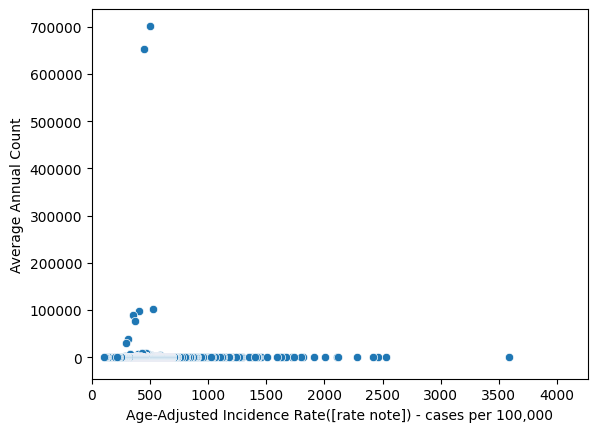

In [32]:
sns.scatterplot(cancer_rates, x='Age-Adjusted Incidence Rate([rate note]) - cases per 100,000', y='Average Annual Count')
plt.xlim(0) # ignore flagged datapoints

(0.0, 200000.0)

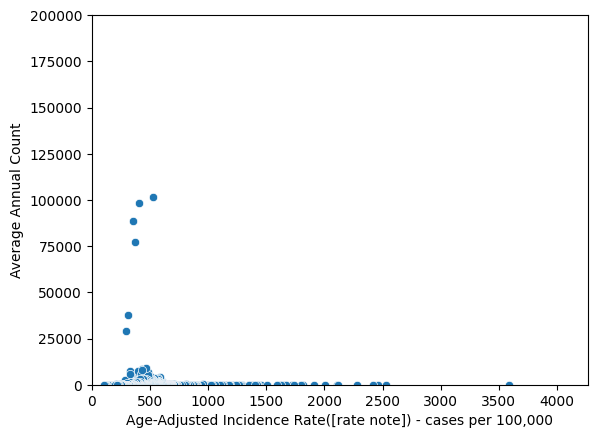

In [33]:
sns.scatterplot(cancer_rates, x='Age-Adjusted Incidence Rate([rate note]) - cases per 100,000', y='Average Annual Count')
plt.xlim(0) # ignore flagged datapoints
plt.ylim(0, 200_000) # Ignore outliers in the 600K-700K range

(0.0, 20000.0)

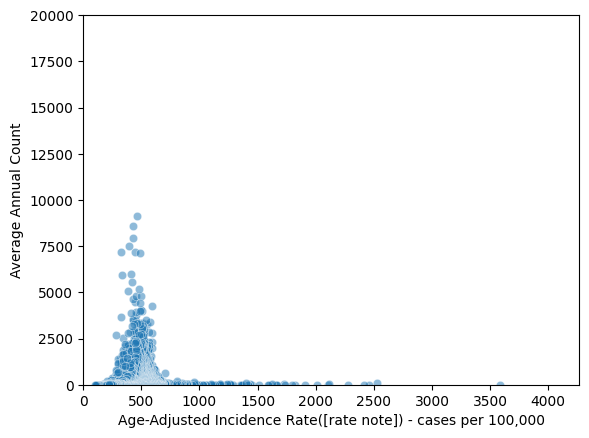

In [34]:
sns.scatterplot(cancer_rates, x='Age-Adjusted Incidence Rate([rate note]) - cases per 100,000', y='Average Annual Count', alpha=0.5)
plt.xlim(0) # ignore flagged datapoints
plt.ylim(0, 20_000) # Ignore outliers in the 25K-100K range

<Axes: xlabel='Recent Trend', ylabel='Recent 5-Year Trend ([trend note]) in Incidence Rates'>

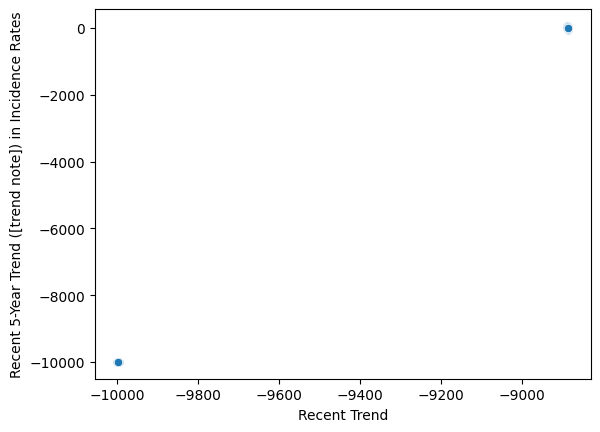

In [35]:
sns.scatterplot(cancer_rates, x='Recent Trend', y='Recent 5-Year Trend ([trend note]) in Incidence Rates')

(0.0, 568.62)

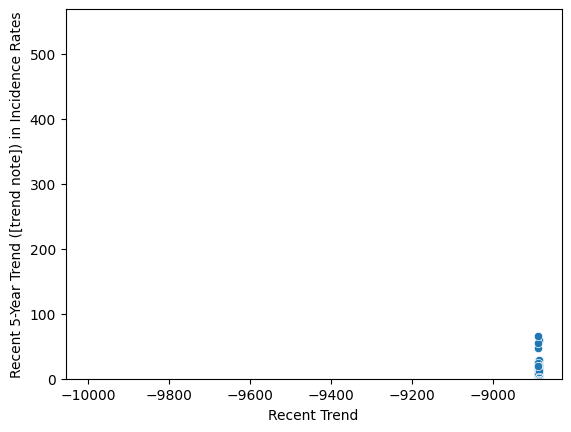

In [36]:
sns.scatterplot(cancer_rates, x='Recent Trend', y='Recent 5-Year Trend ([trend note]) in Incidence Rates')
plt.ylim(0) # ignore flagged datapoints

(-9000.0, -8830.35)

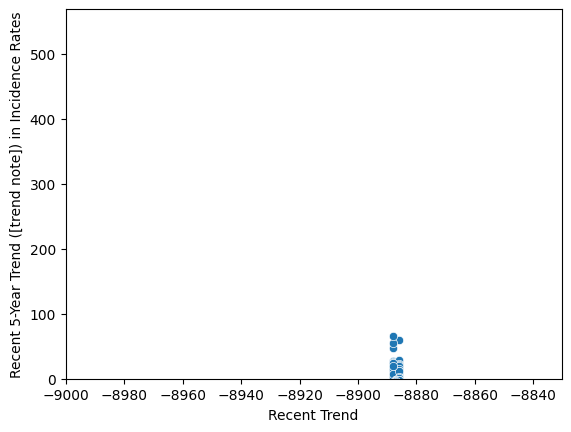

In [37]:
sns.scatterplot(cancer_rates, x='Recent Trend', y='Recent 5-Year Trend ([trend note]) in Incidence Rates')
plt.ylim(0) # ignore flagged datapoints
plt.xlim(-9000)

In [38]:
# Not as useful since the trends are all flagged values
cancer_rates['Recent Trend'].unique()

array([-8888., -9999., -8886., -8887., -9998., -9997., -9996.])

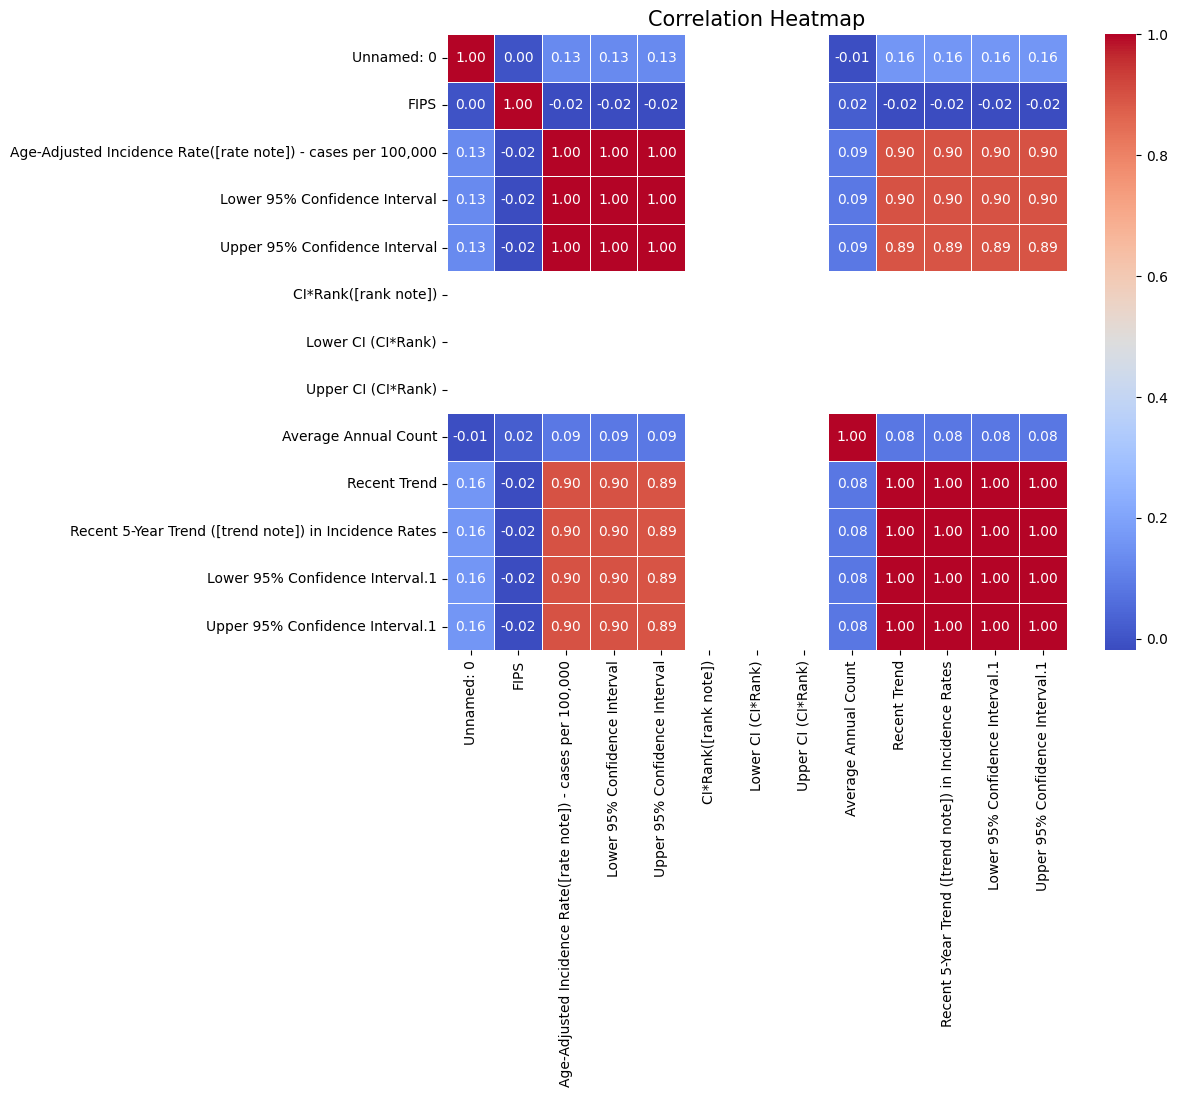

In [39]:
correlation_matrix = cancer_rates.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the actual correlation numbers
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=15)
plt.show()

---

In [54]:
# colspecs format: (Start_Index_Inclusive, End_Index_Exclusive)
col_specs = [
    # --- Previous Sections ---
    (0, 19),    # Reserved Positions (1-19)
    (19, 20),   # Resident Status (20)
    (20, 60),   # Reserved Positions (21-60)
    (60, 64),   # EDUCATION (61-64)
    (64, 66),   # Month of Death (65-66)
    (66, 68),   # Reserved Positions (67-68)
    (68, 69),   # Sex (69)
    (69, 73),   # Detail Age (70-73)
    (73, 74),   # Age Substitution Flag (74)
    (74, 76),   # Age Recode 52 (75-76)
    (76, 78),   # Age Recode 27 (77-78)
    (78, 80),   # Age Recode 12 (79-80)
    (80, 82),   # Infant Age Recode 22 (81-82)
    (82, 83),   # Place of Death and Decedent’s Status (83)
    (83, 84),   # Marital Status (84)
    (84, 85),   # Day of Week of Death (85)
    (85, 101),  # Reserved Positions (86-101)
    (101, 105), # Current Data Year (102-105)
    (105, 106), # Injury at Work (106)
    (106, 107), # Manner of Death (107)
    (107, 108), # Method of Disposition (108)
    (108, 109), # Autopsy (109)
    (109, 143), # Reserved Positions (110-143)
    (143, 144), # Activity Code (144)
    (144, 145), # Place of Injury (145)
    (145, 149), # ICD Code 10th Revision (146-149)
    (149, 152), # 358 Cause Recode (150-152)
    (152, 153), # Reserved Position (153)
    (153, 156), # 113 Cause Recode (154-156)
    (156, 159), # 130 Infant Cause Recode (157-159)
    (159, 161), # 39 Cause Recode (160-161)
    (161, 162), # Reserved Position (162)
    (162, 164), # Number of Entity-Axis Conditions (163-164)
    (164, 304), # ENTITY-AXIS CONDITIONS (165-304)
    (304, 340), # Reserved Positions (305-340)
    (340, 342), # Number of Record-Axis Conditions (341-342)
    (342, 343), # Reserved Position (343)
    (343, 443), # RECORD-AXIS CONDITIONS (344-443)
    (443, 444), # Reserved position (444)
    (444, 446), # Bridged Race (445-446)
    (446, 447), # Bridged Race Flag (447)
    (447, 448), # Race Imputation Flag (448)
    (448, 449), # All other races imputed (449)
    (449, 450), # Bridged Race Recode 5 (450)
    (450, 483), # Reserved (451-483)
    (483, 486), # Hispanic Origin (484-486)
    (486, 487), # Reserved (487)
    (487, 488), # Hispanic Origin/Bridged Race Recode (488)
    (488, 490), # Race Recode 40 (489-490)
    (490, 505), # Reserved (491-505)
    (505, 506), # Race Reporting Flag (506)
    (506, 507), # Hispanic Reporting Flag (507)
    (507, 1330) # Reserved Filler to end (508-1330)
]

column_names = [
    # --- Demographics & Geographic Info ---
    "RESERVED_1",              # 1-19: Reserved Positions
    "RESIDENT_STATUS",         # 20: Resident Status
    "RESERVED_2",              # 21-60: Reserved Positions
    "EDUCATION",               # 61-64: Education (combined)
    "MONTH_OF_DEATH",          # 65-66: Month of Death
    "RESERVED_3",              # 67-68: Reserved Positions
    "SEX",                     # 69: Sex
    "DETAIL_AGE",              # 70-73: Detail Age
    "AGE_SUB_FLAG",            # 74: Age Substitution Flag
    "AGE_RECODE_52",           # 75-76: Age Recode 52
    "AGE_RECODE_27",           # 77-78: Age Recode 27
    "AGE_RECODE_12",           # 79-80: Age Recode 12
    "INFANT_AGE_RECODE_22",    # 81-82: Infant Age Recode 22
    "PLACE_OF_DEATH",          # 83: Place of Death and Decedent’s Status
    "MARITAL_STATUS",          # 84: Marital Status
    "WEEKDAY_OF_DEATH",        # 85: Day of Week of Death
    "RESERVED_4",              # 86-101: Reserved Positions
    "DATA_YEAR",               # 102-105: Current Data Year
    "INJURY_AT_WORK",          # 106: Injury at Work
    "MANNER_OF_DEATH",         # 107: Manner of Death
    "METHOD_DISPOSITION",      # 108: Method of Disposition
    "AUTOPSY",                 # 109: Autopsy
    "RESERVED_5",              # 110-143: Reserved Positions
    "ACTIVITY_CODE",           # 144: Activity Code
    "PLACE_OF_INJURY",         # 145: Place of Injury

    # --- Causes of Death ---
    "ICD_10",                  # 146-149: ICD Code 10th Revision
    "CAUSE_RECODE_358",        # 150-152: 358 Cause Recode
    "RESERVED_6",              # 153: Reserved Position
    "CAUSE_RECODE_113",        # 154-156: 113 Cause Recode
    "INFANT_CAUSE_RECODE_130", # 157-159: 130 Infant Cause Recode
    "CAUSE_RECODE_39",         # 160-161: 39 Cause Recode
    "RESERVED_7",              # 162: Reserved Position
    "ENTITY_CONDITION_COUNT",  # 163-164: Number of Entity-Axis Conditions
    "ENTITY_AXIS_CONDITIONS",  # 165-304: ENTITY-AXIS CONDITIONS
    "RESERVED_8",              # 305-340: Reserved Positions
    "RECORD_CONDITION_COUNT",  # 341-342: Number of Record-Axis Conditions
    "RESERVED_9",              # 343: Reserved Position
    "RECORD_AXIS_CONDITIONS",  # 344-443: RECORD-AXIS CONDITIONS

    # --- Demographics (Race/Origin) ---
    "RESERVED_10",             # 444: Reserved position
    "BRIDGED_RACE",            # 445-446: Bridged Race
    "BRIDGED_RACE_FLAG",       # 447: Bridged Race Flag
    "RACE_IMPUTATION_FLAG",    # 448: Race Imputation Flag
    "OTHER_RACE_IMPUTED",      # 449: All other races imputed
    "BRIDGED_RACE_RECODE_5",   # 450: Bridged Race Recode 5
    "RESERVED_11",             # 451-483: Reserved
    "HISPANIC_ORIGIN",         # 484-486: Hispanic Origin
    "RESERVED_12",             # 487: Reserved
    "HISPANIC_RACE_RECODE",    # 488: Hispanic Origin/Bridged Race Recode
    "RACE_RECODE_40",          # 489-490: Race Recode 40
    "RESERVED_13",             # 491-505: Reserved
    "RACE_REPORT_FLAG",        # 506: Race Reporting Flag
    "HISPANIC_REPORT_FLAG",    # 507: Hispanic Reporting Flag
    "FINAL_FILLER"             # 508-1330: Reserved filler
]

deaths = pd.read_fwf(
    # '../Health Disparities Analytics/Data/Deaths/mort2018us.zip',
    '../Health Disparities Analytics/Data/Deaths/mort2019us.zip',
    # '../Health Disparities Analytics/Data/Deaths/mort2020us.dat',
    compression='zip',
    colspecs=col_specs, 
    names=column_names, 
    header=None, 
    dtype=str,
    # low_memory=False # This prevents Pandas from loading the whole thing before processing

)

print(f"Data Loaded: {len(deaths):,} rows")

deaths.head()

Data Loaded: 2,861,523 rows


,RESERVED_1,RESIDENT_STATUS,RESERVED_2,EDUCATION,MONTH_OF_DEATH,RESERVED_3,SEX,DETAIL_AGE,AGE_SUB_FLAG,AGE_RECODE_52,...,BRIDGED_RACE_RECODE_5,RESERVED_11,HISPANIC_ORIGIN,RESERVED_12,HISPANIC_RACE_RECODE,RACE_RECODE_40,RESERVED_13,RACE_REPORT_FLAG,HISPANIC_REPORT_FLAG,FINAL_FILLER
0,NaN,2,NaN,41,01,NaN,M,1036,NaN,33,...,1,NaN,100,NaN,6,01,NaN,NaN,NaN,NaN
1,NaN,3,NaN,41,01,NaN,F,1063,NaN,38,...,1,NaN,100,NaN,6,01,NaN,NaN,NaN,NaN
2,NaN,1,NaN,31,01,NaN,F,1097,NaN,45,...,1,NaN,100,NaN,6,01,NaN,NaN,NaN,NaN
3,NaN,1,NaN,31,01,NaN,M,1076,NaN,41,...,1,NaN,100,NaN,6,01,NaN,NaN,NaN,NaN
4,NaN,2,NaN,41,01,NaN,M,1064,NaN,38,...,1,NaN,100,NaN,6,01,NaN,NaN,NaN,NaN


In [55]:
# Add a race label for the recoded race 40 column

race_recode_40_map = {
    '01': 'White',
    '02': 'Black',
    '03': 'American Indian or Alaskan Native (AIAN)',
    '04': 'Asian Indian',
    '05': 'Chinese',
    '06': 'Filipino',
    '07': 'Japanese',
    '08': 'Korean',
    '09': 'Vietnamese',
    '10': 'Other or Multiple Asian',
    '11': 'Hawaiian',
    '12': 'Guamanian',
    '13': 'Samoan',
    '14': 'Other or Multiple Pacific Islander',
    '15': 'Black and White',
    '16': 'Black and AIAN',
    '17': 'Black and Asian',
    '18': 'Black and Native Hawaiian or Other Pacific Islander (NHOPI)',
    '19': 'AIAN and White',
    '20': 'AIAN and Asian',
    '21': 'AIAN and NHOPI',
    '22': 'Asian and White',
    '23': 'Asian and NHOPI',
    '24': 'NHOPI and White',
    '25': 'Black, AIAN and White',
    '26': 'Black, AIAN and Asian',
    '27': 'Black, AIAN and NHOPI',
    '28': 'Black, Asian and White',
    '29': 'Black, Asian and NHOPI',
    '30': 'Black, NHOPI and White',
    '31': 'AIAN, Asian and White',
    '32': 'AIAN, NHOPI and White',
    '33': 'AIAN, Asian and NHOPI',
    '34': 'Asian, NHOPI and White',
    '35': 'Black, AIAN, Asian and White',
    '36': 'Black, AIAN, Asian and NHOPI',
    '37': 'Black, AIAN, NHOPI and White',
    '38': 'Black, Asian, NHOPI and White',
    '39': 'AIAN, Asian, NHOPI and White',
    '40': 'Black, AIAN, Asian, NHOPI and White',
    '99': 'Unknown and Other Race'
}

# Apply to your dataframe
deaths['race_label'] = deaths['RACE_RECODE_40'].map(race_recode_40_map)
deaths['race_label'].head(15)

0                                        White
1                                        White
2                                        White
3                                        White
4                                        White
5                                        White
6                                        White
7                                        White
8     American Indian or Alaskan Native (AIAN)
9     American Indian or Alaskan Native (AIAN)
10                                       White
11                              AIAN and White
12    American Indian or Alaskan Native (AIAN)
13                                       White
14                             Asian and White
Name: race_label, dtype: object

In [56]:
deaths.columns

Index(['RESERVED_1', 'RESIDENT_STATUS', 'RESERVED_2', 'EDUCATION',
       'MONTH_OF_DEATH', 'RESERVED_3', 'SEX', 'DETAIL_AGE', 'AGE_SUB_FLAG',
       'AGE_RECODE_52', 'AGE_RECODE_27', 'AGE_RECODE_12',
       'INFANT_AGE_RECODE_22', 'PLACE_OF_DEATH', 'MARITAL_STATUS',
       'WEEKDAY_OF_DEATH', 'RESERVED_4', 'DATA_YEAR', 'INJURY_AT_WORK',
       'MANNER_OF_DEATH', 'METHOD_DISPOSITION', 'AUTOPSY', 'RESERVED_5',
       'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'ICD_10', 'CAUSE_RECODE_358',
       'RESERVED_6', 'CAUSE_RECODE_113', 'INFANT_CAUSE_RECODE_130',
       'CAUSE_RECODE_39', 'RESERVED_7', 'ENTITY_CONDITION_COUNT',
       'ENTITY_AXIS_CONDITIONS', 'RESERVED_8', 'RECORD_CONDITION_COUNT',
       'RESERVED_9', 'RECORD_AXIS_CONDITIONS', 'RESERVED_10', 'BRIDGED_RACE',
       'BRIDGED_RACE_FLAG', 'RACE_IMPUTATION_FLAG', 'OTHER_RACE_IMPUTED',
       'BRIDGED_RACE_RECODE_5', 'RESERVED_11', 'HISPANIC_ORIGIN',
       'RESERVED_12', 'HISPANIC_RACE_RECODE', 'RACE_RECODE_40', 'RESERVED_13',
       'RA

In [57]:
print(deaths['EDUCATION'].head(10).tolist())

['41', '41', '31', '31', '41', '81', '71', '61', '11', '31']


In [58]:
# Due to the different revisions 1989 and 2003, I need to restructure the codes for education


# -------------------- EDUCATION VALUE ---------------------------------------
# Category              1989 Codes (Years)              2003 Codes (Categories)
# Less than HS          00-11                           1,2
# HS Grad / GED         12                              3
# Some College          13-15                           4,5
# Bachelors Degree      16                              6
# Advanced Degree       17                              7,8
# Unknown/Not Stated    99                              9

# -------------------- EDUCATION REPORTING FLAG --------------------------------
# Flag Code             CDC Revison                     Meaning             
# 0                     1989                            Value represents Years (00-17)
# 1                     2003                            Value represents Categories (1-8)
# 2                                                     No education information was collected


def restructure_education(row):

    # Get rid of white space
    val = str(row['education_value']).strip()
    flag = str(row['education_reporting_flag']).strip()

    # Handle Unknown/Not Reported
    if val in ['99' or '9'] or flag == '2':
        return "Unknown"
    
    # Handle 2003 Revision (Categorial values)
    if flag == '1':
        mapping = {
            '1': 'Less than HS', '2': 'Less than HS',
            '3': 'HS Grad',
            '4': 'Some College', '5': 'Some College',
            '6': 'Bachelors',
            '7': 'Advanced Degree', '8': 'Advanced Degree'
        }
        return mapping.get(val, "Unknown")
    
    # Handle 1989 Revision (Years)
    if flag == '0':
        try:
            years = int(val)
            if years < 12: return 'Less than HS'
            if years == 12: return 'HS Grad / GED'
            if 13 <= years <= 15: return 'Some College'
            if years == 16: return 'Bachelors Degree'
            if years > 16: return 'Advanced Degree'
        except ValueError:
            return "Unknown"
        
    # Mark unknown if data is outside of the logic (human errors/messed up data)
    return "Unknown"

In [59]:
# Using a vectorized approach in order to save memory space


'''
    AI ACKNOWLEDGEMENT:

    Used Google Gemini to convert my function into vectorized form so that I can save memory space since the file is large.
    I prompted Google Gemini with my code and the MemoryError Traceback output and asked it to find another way to apply this
    logic to the dataframe. This gives me starter code that I can troubleshoot and adapt for my dataset.

    Gemini:
    That MemoryError is a common rite of passage for data science graduate students working with large-scale datasets. The CDC 
    mortality files contain millions of records (your error shows over 2.8 million rows), and df.apply(axis=1) is notoriously 
    memory-heavy because it creates many intermediate Python objects in your RAM.

    To solve this for your project, we need to switch from row-wise processing to vectorized operations, which handle entire columns 
    at once using C-based optimizations.

    Why you hit this error
    The CDC File Size: These files are massive flat files.

    The .apply() bottleneck: Using .apply(axis=1) is like a worker looking at every single row one by one and writing down a new result 
    on a separate sheet of paper. It uses a massive amount of memory to hold all those temporary results before finalizing the column.

    The Vectorized Solution (Memory Efficient)
    Instead of a function, we use numpy.select() or pandas .loc. This is much faster and uses significantly less RAM.

    import numpy as np

    # 1. Ensure columns are strings and stripped
    deaths_2018['education_value'] = deaths_2018['EDUCATION'].str.slice(0, 3).str.strip()
    deaths_2018['education_reporting_flag'] = deaths_2018['EDUCATION'].str.slice(3, 4).str.strip()

    # 2. Define the conditions
    val = deaths_2018['education_value']
    flag = deaths_2018['education_reporting_flag']

    conditions = [
        # Flag 2 or Unknown values
        (flag == '2') | (val.isin(['99', '9'])),
        
        # 2003 Revision (Flag 1)
        (flag == '1') & (val.isin(['1', '2'])),
        (flag == '1') & (val == '3'),
        (flag == '1') & (val.isin(['4', '5'])),
        (flag == '1') & (val == '6'),
        (flag == '1') & (val.isin(['7', '8'])),
        
        # 1989 Revision (Flag 0) - Using string comparisons for speed
        (flag == '0') & (val.astype(float) < 12),
        (flag == '0') & (val.astype(float) == 12),
        (flag == '0') & (val.astype(float).between(13, 15)),
        (flag == '0') & (val.astype(float) == 16),
        (flag == '0') & (val.astype(float) > 16)
    ]

    choices = [
        'Unknown',
        'Less than HS', 'HS Grad', 'Some College', 'Bachelors', 'Advanced Degree',
        'Less than HS', 'HS Grad', 'Some College', 'Bachelors', 'Advanced Degree'
    ]

    # 3. Create the column
    deaths_2018['edu_standardized'] = np.select(conditions, choices, default='Unknown')

'''

# 1. Ensure columns are strings and stripped - last character is the flag, everything before it is the value
deaths['education_reporting_flag'] = deaths['EDUCATION'].str.strip().str.slice(-1)
deaths['education_value'] = deaths['EDUCATION'].str.strip().str.slice(0, -1).str.strip()

# 2. 'Coerce' to turn blanks into NaN
val_num = pd.to_numeric(deaths['education_value'], errors='coerce')

# 3. Define the conditions
val = deaths['education_value']
flag = deaths['education_reporting_flag']

conditions = [
    # Flag 2 or Unknown values (99, 9) or empty values
    (flag == '2') | (val.isin(['99', '9', ''])),
    
    # 2003 Revision (Flag 1)
    (flag == '1') & (val.isin(['1', '2'])),
    (flag == '1') & (val == '3'),
    (flag == '1') & (val.isin(['4', '5'])),
    (flag == '1') & (val == '6'),
    (flag == '1') & (val.isin(['7', '8'])),
    
    # 1989 Revision (Flag 0)
    (flag == '0') & (val_num < 12),
    (flag == '0') & (val_num == 12),
    (flag == '0') & (val_num >= 13) & (val_num <= 15),
    (flag == '0') & (val_num == 16),
    (flag == '0') & (val_num > 16)
]

choices = [
    'Unknown',
    'Less than HS', 'HS Grad / GED', 'Some College', 'Bachelors Degree', 'Advanced Degree',
    'Less than HS', 'HS Grad / GED', 'Some College', 'Bachelors Degree', 'Advanced Degree'
]

# 3. Create the column
deaths['edu_standardized'] = np.select(conditions, choices, default='Unknown')

print(deaths['edu_standardized'].value_counts())

edu_standardized
HS Grad / GED       1215215
Less than HS         554495
Some College         546060
Bachelors Degree     309185
Advanced Degree      184369
Unknown               52199
Name: count, dtype: int64


In [60]:
broad_cardio = deaths[deaths['CAUSE_RECODE_113'] == '051'].shape[0]
specific_heart = deaths[deaths['CAUSE_RECODE_113'] == '052'].shape[0]

print(f"Broad (051): {broad_cardio}")
print(f"Specific Heart (052): {specific_heart}")

Broad (051): 35327
Specific Heart (052): 121540


In [61]:
cause_113_map = {
    '001': 'Salmonella infections (A01-A02)',
    '002': 'Shigellosis and amebiasis (A03, A06)',
    '003': 'Certain other intestinal infections (A04, A07-A09)',
    '004': 'Tuberculosis (A16-A19)',
    '005': 'Respiratory tuberculosis (A16)',
    '006': 'Other tuberculosis (A17-A19)',
    '007': 'Whooping cough (A37)',
    '008': 'Scarlet fever and erysipelas (A38, A46)',
    '009': 'Meningococcal infection (A39)',
    '010': 'Septicemia (A40-A41)',
    '011': 'Syphilis (A50-A53)',
    '012': 'Acute poliomyelitis (A80)',
    '013': 'Arthropod-borne viral encephalopathy (A83-A84, A85.2)',
    '014': 'Measles (B05)',
    '015': 'Viral hepatitis (B15-B19)',
    '016': 'Human immunodeficiency virus (HIV) disease (B20-B24)',
    '017': 'Malaria (B50-B54)',
    '018': 'Other and unspecified infectious and parasitic diseases',
    '019': 'Malignant neoplasms (C00-C97)',
    '020': 'Malignant neoplasms of lip, oral cavity and pharynx (C00-C14)',
    '021': 'Malignant neoplasm of esophagus (C15)',
    '022': 'Malignant neoplasm of stomach (C16)',
    '023': 'Malignant neoplasms of colon, rectum and anus (C18-C21)',
    '024': 'Malignant neoplasms of liver and intrahepatic bile ducts (C22)',
    '025': 'Malignant neoplasm of pancreas (C25)',
    '026': 'Malignant neoplasm of larynx (C32)',
    '027': 'Malignant neoplasms of trachea, bronchus and lung (C33-C34)',
    '028': 'Malignant melanoma of skin (C43)',
    '029': 'Malignant neoplasm of breast (C50)',
    '030': 'Malignant neoplasm of cervix uteri (C53)',
    '031': 'Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)',
    '032': 'Malignant neoplasm of ovary (C56)',
    '033': 'Malignant neoplasm of prostate (C61)',
    '034': 'Malignant neoplasms of kidney and renal pelvis (C64-C65)',
    '035': 'Malignant neoplasm of bladder (C67)',
    '036': 'Malignant neoplasms of meninges, brain and other parts of central nervous system (C70-C72)',
    '037': 'Hodgkin disease (C81)',
    '038': 'Non-Hodgkin lymphoma (C82-C85)',
    '039': 'Leukemia (C91-C95)',
    '040': 'Multiple myeloma and immunoproliferative neoplasms (C88, C90)',
    '041': 'Other and unspecified malignant neoplasms',
    '042': 'In situ neoplasms, benign neoplasms and neoplasms of uncertain or unknown behavior',
    '043': 'Anemias (D50-D64)',
    '044': 'Diabetes mellitus (E10-E14)',
    '045': 'Nutritional deficiencies (E40-E64)',
    '046': 'Malnutrition (E40-E46)',
    '047': 'Other nutritional deficiencies (E50-E64)',
    '048': 'Meningitis (G00, G03)',
    '049': 'Parkinson disease (G20-G21)',
    '050': 'Alzheimer disease (G30)',
    '051': 'Major cardiovascular diseases (I00-I78)',
    '052': 'Diseases of heart (I00-I09, I11, I13, I20-I51)',
    '053': 'Acute rheumatic fever and chronic rheumatic heart diseases (I00-I09)',
    '054': 'Hypertensive heart disease (I11)',
    '055': 'Hypertensive heart and renal disease (I13)',
    '056': 'Ischemic heart diseases (I20-I25)',
    '057': 'Acute myocardial infarction (I21-I22)',
    '058': 'Other acute ischemic heart diseases (I24)',
    '059': 'Other forms of chronic ischemic heart disease (I20, I25)',
    '060': 'Atherosclerotic cardiovascular disease, so described (I25.0)',
    '061': 'All other forms of chronic ischemic heart disease (I20, I25.1-I25.9)',
    '062': 'Other diseases of heart (I26-I51)',
    '063': 'Heart failure (I50)',
    '064': 'All other forms of heart disease',
    '065': 'Essential (primary) hypertension and hypertensive renal disease (I10, I12, I15)',
    '066': 'Cerebrovascular diseases (I60-I69)',
    '067': 'Atherosclerosis (I70)',
    '068': 'Aortic aneurysm and dissection (I71)',
    '069': 'Other diseases of arteries, arterioles and capillaries (I72-I78)',
    '070': 'Other disorders of circulatory system (I80-I99)',
    '071': 'Influenza and pneumonia (J09-J18)',
    '072': 'Influenza (J09-J11)',
    '073': 'Pneumonia (J12-J18)',
    '074': 'Other acute lower respiratory infections (J20-J22)',
    '075': 'Acute bronchitis and bronchiolitis (J20-J21)',
    '076': 'Unspecified acute lower respiratory infection (J22)',
    '077': 'Chronic lower respiratory diseases (J40-J47)',
    '078': 'Bronchitis, chronic and unspecified (J40-J42)',
    '079': 'Emphysema (J43)',
    '080': 'Asthma (J45-J46)',
    '081': 'Other chronic lower respiratory diseases (J44, J47)',
    '082': 'Pneumonoconioses and chemical effects (J60-J66, J68)',
    '083': 'Pneumonitis due to solids and liquids (J69)',
    '084': 'Other diseases of respiratory system',
    '085': 'Peptic ulcer (K25-K28)',
    '086': 'Diseases of appendix (K35-K38)',
    '087': 'Hernia (K40-K46)',
    '088': 'Chronic liver disease and cirrhosis (K70, K73-K74)',
    '089': 'Alcoholic liver disease (K70)',
    '090': 'Other chronic liver disease and cirrhosis (K73-K74)',
    '091': 'Cholelithiasis and other disorders of gallbladder (K80-K82)',
    '092': 'Nephritis, nephrotic syndrome and nephrosis (N00-N07, N17-N19, N25-N27)',
    '093': 'Acute and rapidly progressive nephritic and nephrotic syndrome (N00-N01, N04)',
    '094': 'Chronic glomerulonephritis, nephritis/nephrosis, etc. (N02-N03, N05-N07, N26)',
    '095': 'Renal failure (N17-N19)',
    '096': 'Other disorders of kidney (N25, N27)',
    '097': 'Infections of kidney (N10-N12, N13.6, N15.1)',
    '098': 'Hyperplasia of prostate (N40)',
    '099': 'Inflammatory diseases of female pelvic organs (N70-N76)',
    '100': 'Pregnancy, childbirth and the puerperium (O00-O99)',
    '101': 'Pregnancy with abortive outcome (O00-O07)',
    '102': 'Other complications of pregnancy, childbirth and the puerperium (O10-O99)',
    '103': 'Certain conditions originating in the perinatal period (P00-P96)',
    '104': 'Congenital malformations, deformations and chromosomal abnormalities (Q00-Q99)',
    '105': 'Symptoms, signs and abnormal clinical and laboratory findings, NEC (R00-R99)',
    '106': 'All other diseases (Residual)',
    '107': 'Accidents (unintentional injuries) (V01-X59, Y85-Y86)',
    '108': 'Transport accidents (V01-V99, Y85)',
    '109': 'Motor vehicle accidents (V02-V04, V09.0, V09.2, V12-V14, V19.0-V19.6, V20-V79, V80.3-V80.5, V81.0-V81.1, V82.0-V82.1, V83-V86, V87.0-V87.8, V88.0-V88.8, V89.0, V89.2)',
    '110': 'Other land transport accidents',
    '111': 'Water, air and space, and other and unspecified transport accidents',
    '112': 'Nontransport accidents (W00-X59, Y86)',
    '113': 'Falls (W00-W19)',
    '114': 'Accidental discharge of firearms (W32-W34)',
    '115': 'Accidental drowning and submersion (W65-W74)',
    '116': 'Accidental exposure to smoke, fire and flames (X00-X09)',
    '117': 'Accidental poisoning and exposure to noxious substances (X40-X49)',
    '118': 'Other nontransport accidents',
    '119': 'Intentional self-harm (suicide) (*U03, X60-X84, Y87.0)',
    '120': 'Assault (homicide) (*U01-*U02, X85-Y09, Y87.1)',
    '121': 'Legal intervention (Y35, Y89.0)',
    '122': 'Events of undetermined intent (Y10-Y34, Y87.2, Y89.9)',
    '123': 'Operations of war and their sequelae (Y36, Y89.1)',
    '124': 'Complications of medical and surgical care (Y40-Y84, Y88)'
}

# 2020 version
# cause_113_map = {
#     '001': 'Salmonella infections (A01-A02)',
#     '002': 'Shigellosis and amebiasis (A03, A06)',
#     '003': 'Certain other intestinal infections (A04, A07-A09)',
#     '004': 'Tuberculosis (A16-A19)',
#     '005': 'Respiratory tuberculosis (A16)',
#     '006': 'Other tuberculosis (A17-A19)',
#     '007': 'Whooping cough (A37)',
#     '008': 'Scarlet fever and erysipelas (A38, A46)',
#     '009': 'Meningococcal infection (A39)',
#     '010': 'Septicemia (A40-A41)',
#     '011': 'Syphilis (A50-A53)',
#     '012': 'COVID-19 (U07.1)',  # Added for 2020 consistency
#     '013': 'Arthropod-borne viral encephalopathy (A83-A84, A85.2)',
#     '014': 'Measles (B05)',
#     '015': 'Viral hepatitis (B15-B19)',
#     '016': 'Human immunodeficiency virus (HIV) disease (B20-B24)',
#     '017': 'Malaria (B50-B54)',
#     '018': 'Other and unspecified infectious and parasitic diseases',
#     '019': 'Malignant neoplasms (C00-C97)',
#     '020': 'Malignant neoplasms of lip, oral cavity and pharynx (C00-C14)',
#     '021': 'Malignant neoplasm of esophagus (C15)',
#     '022': 'Malignant neoplasm of stomach (C16)',
#     '023': 'Malignant neoplasms of colon, rectum and anus (C18-C21)',
#     '024': 'Malignant neoplasms of liver and intrahepatic bile ducts (C22)',
#     '025': 'Malignant neoplasm of pancreas (C25)',
#     '026': 'Malignant neoplasm of larynx (C32)',
#     '027': 'Malignant neoplasms of trachea, bronchus and lung (C33-C34)',
#     '028': 'Malignant melanoma of skin (C43)',
#     '029': 'Malignant neoplasm of breast (C50)',
#     '030': 'Malignant neoplasm of cervix uteri (C53)',
#     '031': 'Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)',
#     '032': 'Malignant neoplasm of ovary (C56)',
#     '033': 'Malignant neoplasm of prostate (C61)',
#     '034': 'Malignant neoplasms of kidney and renal pelvis (C64-C65)',
#     '035': 'Malignant neoplasm of bladder (C67)',
#     '036': 'Malignant neoplasms of meninges, brain and other parts of central nervous system (C70-C72)',
#     '037': 'Hodgkin disease (C81)',
#     '038': 'Non-Hodgkin lymphoma (C82-C85)',
#     '039': 'Leukemia (C91-C95)',
#     '040': 'Multiple myeloma and immunoproliferative neoplasms (C88, C90)',
#     '041': 'Other and unspecified malignant neoplasms',
#     '042': 'In situ neoplasms, benign neoplasms and neoplasms of uncertain or unknown behavior',
#     '043': 'Anemias (D50-D64)',
#     '044': 'Diabetes mellitus (E10-E14)',
#     '045': 'Nutritional deficiencies (E40-E64)',
#     '046': 'Malnutrition (E40-E46)',
#     '047': 'Other nutritional deficiencies (E50-E64)',
#     '048': 'Meningitis (G00, G03)',
#     '049': 'Parkinson disease (G20-G21)',
#     '050': 'Alzheimer disease (G30)',
#     '051': 'Major cardiovascular diseases (I00-I78)',
#     '052': 'Diseases of heart (I00-I09, I11, I13, I20-I51)',
#     '053': 'Acute rheumatic fever and chronic rheumatic heart diseases (I00-I09)',
#     '054': 'Hypertensive heart disease (I11)',
#     '055': 'Hypertensive heart and renal disease (I13)',
#     '056': 'Ischemic heart diseases (I20-I25)',
#     '057': 'Acute myocardial infarction (I21-I22)',
#     '058': 'Other acute ischemic heart diseases (I24)',
#     '059': 'Other forms of chronic ischemic heart disease (I20, I25)',
#     '060': 'Atherosclerotic cardiovascular disease, so described (I25.0)',
#     '061': 'All other forms of chronic ischemic heart disease (I20, I25.1-I25.9)',
#     '062': 'Other diseases of heart (I26-I51)',
#     '063': 'Heart failure (I50)',
#     '064': 'All other forms of heart disease',
#     '065': 'Essential (primary) hypertension and hypertensive renal disease (I10, I12, I15)',
#     '066': 'Cerebrovascular diseases (I60-I69)',
#     '067': 'Atherosclerosis (I70)',
#     '068': 'Aortic aneurysm and dissection (I71)',
#     '069': 'Other diseases of arteries, arterioles and capillaries (I72-I78)',
#     '070': 'Other disorders of circulatory system (I80-I99)',
#     '071': 'Influenza and pneumonia (J09-J18)',
#     '072': 'Influenza (J09-J11)',
#     '073': 'Pneumonia (J12-J18)',
#     '074': 'Other acute lower respiratory infections (J20-J22)',
#     '075': 'Acute bronchitis and bronchiolitis (J20-J21)',
#     '076': 'Unspecified acute lower respiratory infection (J22)',
#     '077': 'Chronic lower respiratory diseases (J40-J47)',
#     '078': 'Bronchitis, chronic and unspecified (J40-J42)',
#     '079': 'Emphysema (J43)',
#     '080': 'Asthma (J45-J46)',
#     '081': 'Other chronic lower respiratory diseases (J44, J47)',
#     '082': 'Pneumonoconioses and chemical effects (J60-J66, J68)',
#     '083': 'Pneumonitis due to solids and liquids (J69)',
#     '084': 'Other diseases of respiratory system',
#     '085': 'Peptic ulcer (K25-K28)',
#     '086': 'Diseases of appendix (K35-K38)',
#     '087': 'Hernia (K40-K46)',
#     '088': 'Chronic liver disease and cirrhosis (K70, K73-K74)',
#     '089': 'Alcoholic liver disease (K70)',
#     '090': 'Other chronic liver disease and cirrhosis (K73-K74)',
#     '091': 'Cholelithiasis and other disorders of gallbladder (K80-K82)',
#     '092': 'Nephritis, nephrotic syndrome and nephrosis (N00-N07, N17-N19, N25-N27)',
#     '093': 'Acute and rapidly progressive nephritic and nephrotic syndrome (N00-N01, N04)',
#     '094': 'Chronic glomerulonephritis, nephritis/nephrosis, etc. (N02-N03, N05-N07, N26)',
#     '095': 'Renal failure (N17-N19)',
#     '096': 'Other disorders of kidney (N25, N27)',
#     '097': 'Infections of kidney (N10-N12, N13.6, N15.1)',
#     '098': 'Hyperplasia of prostate (N40)',
#     '099': 'Inflammatory diseases of female pelvic organs (N70-N76)',
#     '100': 'Pregnancy, childbirth and the puerperium (O00-O99)',
#     '101': 'Pregnancy with abortive outcome (O00-O07)',
#     '102': 'Other complications of pregnancy, childbirth and the puerperium (O10-O99)',
#     '103': 'Certain conditions originating in the perinatal period (P00-P96)',
#     '104': 'Congenital malformations, deformations and chromosomal abnormalities (Q00-Q99)',
#     '105': 'Symptoms, signs and abnormal clinical and laboratory findings, NEC (R00-R99)',
#     '106': 'All other diseases (Residual)',
#     '107': 'Accidents (unintentional injuries) (V01-X59, Y85-Y86)',
#     '108': 'Transport accidents (V01-V99, Y85)',
#     '109': 'Motor vehicle accidents (V02-V04, V09.0, V09.2, V12-V14, V19.0-V19.6, V20-V79, V80.3-V80.5, V81.0-V81.1, V82.0-V82.1, V83-V86, V87.0-V87.8, V88.0-V88.8, V89.0, V89.2)',
#     '110': 'Other land transport accidents',
#     '111': 'Water, air and space, and other and unspecified transport accidents',
#     '112': 'Nontransport accidents (W00-X59, Y86)',
#     '113': 'Falls (W00-W19)',
#     '114': 'Accidental discharge of firearms (W32-W34)',
#     '115': 'Accidental drowning and submersion (W65-W74)',
#     '116': 'Accidental exposure to smoke, fire and flames (X00-X09)',
#     '117': 'Accidental poisoning and exposure to noxious substances (X40-X49)',
#     '118': 'Other nontransport accidents',
#     '119': 'Intentional self-harm (suicide) (*U03, X60-X84, Y87.0)',
#     '120': 'Assault (homicide) (*U01-*U02, X85-Y09, Y87.1)',
#     '121': 'Legal intervention (Y35, Y89.0)',
#     '122': 'Events of undetermined intent (Y10-Y34, Y87.2, Y89.9)',
#     '123': 'Operations of war and their sequelae (Y36, Y89.1)',
#     '124': 'Complications of medical and surgical care (Y40-Y84, Y88)'
# }
# Apply to your dataframe
deaths['cause_label'] = deaths['CAUSE_RECODE_113'].map(cause_113_map)

In [62]:
# Verifying the original counts were not altered.

# Group by the cause label and the original cause recode 113 column and get the count
cause_audit = deaths.groupby(['CAUSE_RECODE_113', 'cause_label']).size().reset_index(name='count')

heart_check = cause_audit[cause_audit['CAUSE_RECODE_113'].isin(['051', '052'])]

print("--- Cause Label Verification ---")
print(heart_check)

# Verify the totals match your previous variables
print(f"\nVerification of Broad (051) matches: {heart_check[heart_check['CAUSE_RECODE_113'] == '051']['count'].values[0] == broad_cardio}")
print(f"Verification of Specific (052) matches: {heart_check[heart_check['CAUSE_RECODE_113'] == '052']['count'].values[0] == specific_heart}")

--- Cause Label Verification ---
   CAUSE_RECODE_113                                     cause_label   count
45              051         Major cardiovascular diseases (I00-I78)   35327
46              052  Diseases of heart (I00-I09, I11, I13, I20-I51)  121540

Verification of Broad (051) matches: True
Verification of Specific (052) matches: True


In [63]:
infant_maternal_map = {
    '125': 'Certain conditions originating in the perinatal period (P00-P96)',
    '126': 'Congenital malformations, deformations and chromosomal abnormalities (Q00-Q99)',
    '127': 'Symptoms, signs and abnormal clinical and laboratory findings, NEC (R00-R99)',
    '128': 'All other diseases (Residual)',
    '129': 'Accidents (unintentional injuries) (V01-X59, Y85-Y86)',
    '130': 'Intentional self-harm (suicide) (*U03, X60-X84, Y87.0)',
    '131': 'Assault (homicide) (*U01-*U02, X85-Y09, Y87.1)',
    '132': 'Legal intervention (Y35, Y89.0)',
    '133': 'Events of undetermined intent (Y10-Y34, Y87.2, Y89.9)',
    '134': 'Operations of war and their sequelae (Y36, Y89.1)',
    '135': 'Complications of medical and surgical care (Y40-Y84, Y88)'
}

# Update your existing map
cause_113_map.update(infant_maternal_map)

# Re-run the mapping
deaths['cause_label'] = deaths['CAUSE_RECODE_113'].map(cause_113_map)

In [64]:
# Find any codes that failed to map
unmapped = deaths[deaths['cause_label'].isna()]['CAUSE_RECODE_113'].unique()

if len(unmapped) > 0:
    print(f"WARNING: The following codes are unmapped: {unmapped}")
else:
    print("SUCCESS: All codes in the dataset have been labeled.")

# Check for 'One-to-Many' errors (where one code has two different labels)
mapping_consistency = deaths.groupby('CAUSE_RECODE_113')['cause_label'].nunique()
if mapping_consistency.max() > 1:
    print("ERROR: Some codes have multiple labels assigned to them!")

SUCCESS: All codes in the dataset have been labeled.


In [65]:
# Filter the data for only the cause of deaths I am looking for: cancers

# 019 is the 'Broad' category for all Malignant neoplasms
# 020-041 are the specific types (Lung, Breast, Prostate, etc.)
cancer_codes = [str(i).zfill(3) for i in range(19, 42)]
is_cancer = deaths['CAUSE_RECODE_113'].isin(cancer_codes)

cancer_df = deaths[is_cancer]

# Save Cancer Death data to a new CSV file
# cancer_df.to_csv('../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2018.csv', index=False)
cancer_df.to_csv('../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2019.csv', index=False)
# cancer_df.to_csv('../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2020.csv', index=False)

# Next, combine 2018, 2019, 2020 Cancer Death data into one dataset

In [ ]:
files = {
    '../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2018.csv': 2018,
    '../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2019.csv': 2019,
    '../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2020.csv': 2020
}

all_dfs = []

# open files, add year data column
for file, year in files.items():
    print(f"Processing {file}...")

    temp_df = pd.read_csv(file)
    temp_df['Year'] = year

    all_dfs.append(temp_df)

# Combine DFs into one
combined = pd.concat(all_dfs, ignore_index=True)
combined.to_csv('../Health Disparities Analytics/Processed Data/(COMBINED) cancer_deaths.csv', index=False)

print("\nSuccess! Combined file created with 'Year' column.")


Processing ../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2018.csv...
Processing ../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2019.csv...
Processing ../Health Disparities Analytics/Data/Deaths/Filtered Data/cancer_deaths_2020.csv...

Success! Combined file created with 'Year' column.


# Process Combined Cancer Mortality Data - Clean Up Recoded Columns for Analysis Later

In [104]:
cancer_mort = pd.read_csv('../Health Disparities Analytics/Processed Data/(COMBINED) cancer_deaths.csv')

In [105]:
# Standardize the Age column
cancer_mort['DETAIL_AGE'] = pd.to_numeric(cancer_mort['DETAIL_AGE'], errors='coerce')

# Extract Prefix and Units based on user guides' DETAIL_AGE structure
val = cancer_mort['DETAIL_AGE']
prefix = val // 1000
units = val % 1000

conditions = [
    (val == 9999) | (val.isna()),   # Unknown age
    (prefix == 1),                  # Years
    (prefix == 2),                  # Months
    (prefix == 4),                  # Days
    (prefix == 5),                  # Hours
    (prefix == 6)                   # Minutes
]

choices = [
    np.nan,                         # Unknown
    units.astype(float),            # Years
    units / 12,                     # Months
    units / 365.25,                 # Days
    units / (365.25 * 24),          # Hours
    units / (365.25 * 24 * 60)      # Minutes
]

cancer_mort['AGE'] = np.select(conditions, choices, default=np.nan)
cancer_mort.loc[cancer_mort['AGE'] > 125, 'AGE'] = np.nan

print(f"Age processing complete.")
print(f"Max Age: {cancer_mort['AGE'].max():.1f}")
print(f"Min Age (Infant): {cancer_mort['AGE'].min():.5f}")

Age processing complete.
Max Age: 111.0
Min Age (Infant): 0.00010


In [106]:
infant_recode_map = {
    '01': "Under 1 hour", 
    '02': "1 - 23 hours", 
    '03': "1 day", 
    '04': "2 days", 
    '05': "3 days", 
    '06': "4 days", 
    '07': "5 days", 
    '08': "6 days", 
    '09': "7 - 13 days", 
    '10': "14 - 20 days", 
    '11': "21 - 27 days", 
    '12': "1 month", 
    '13': "2 months", 
    '14': "3 months", 
    '15': "4 months", 
    '16': "5 months", 
    '17': "6 months", 
    '18': "7 months", 
    '19': "8 months", 
    '20': "9 months", 
    '21': "10 months", 
    '22': "11 months", 

    # Missing values or NaN values should be handled and then when I use the new infant column, 
    # just ignore the 1 year and over data and use the AGE column instead
    '  ': "1 year and over",        
    np.nan: "1 year and over"
}

cancer_mort['INFANT_AGE'] = cancer_mort['INFANT_AGE_RECODE_22'].astype(str).str.strip().map(infant_recode_map)

In [107]:
cancer_mort['AGE']

0          93.0
1          61.0
2          63.0
3          67.0
4          76.0
           ... 
1578484    55.0
1578485    71.0
1578486    73.0
1578487    54.0
1578488    70.0
Name: AGE, Length: 1578489, dtype: float64

In [108]:
columns_to_drop = [
    'DETAIL_AGE', 'AGE_SUB_FLAG', 'AGE_RECODE_52', 
    'AGE_RECODE_27', 'AGE_RECODE_12', 'INFANT_AGE_RECODE_22'
]

In [109]:
# Using errors='ignore' in case some columns were already removed
cancer_mort.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [110]:
cancer_mort.columns

Index(['RESERVED_1', 'RESIDENT_STATUS', 'RESERVED_2', 'EDUCATION',
       'MONTH_OF_DEATH', 'RESERVED_3', 'SEX', 'PLACE_OF_DEATH',
       'MARITAL_STATUS', 'WEEKDAY_OF_DEATH', 'RESERVED_4', 'DATA_YEAR',
       'INJURY_AT_WORK', 'MANNER_OF_DEATH', 'METHOD_DISPOSITION', 'AUTOPSY',
       'RESERVED_5', 'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'ICD_10',
       'CAUSE_RECODE_358', 'RESERVED_6', 'CAUSE_RECODE_113',
       'INFANT_CAUSE_RECODE_130', 'CAUSE_RECODE_39', 'RESERVED_7',
       'ENTITY_CONDITION_COUNT', 'ENTITY_AXIS_CONDITIONS', 'RESERVED_8',
       'RECORD_CONDITION_COUNT', 'RESERVED_9', 'RECORD_AXIS_CONDITIONS',
       'RESERVED_10', 'BRIDGED_RACE', 'BRIDGED_RACE_FLAG',
       'RACE_IMPUTATION_FLAG', 'OTHER_RACE_IMPUTED', 'BRIDGED_RACE_RECODE_5',
       'RESERVED_11', 'HISPANIC_ORIGIN', 'RESERVED_12', 'HISPANIC_RACE_RECODE',
       'RACE_RECODE_40', 'RESERVED_13', 'RACE_REPORT_FLAG',
       'HISPANIC_REPORT_FLAG', 'FINAL_FILLER', 'race_label',
       'education_reporting_flag', 'educa

In [111]:
# Demographics:

sex_map = {'M': 'Male', 'F': 'Female'}

marital_map = {
    'S': 'Never Married', 'M': 'Married', 'W': 'Widowed', 
    'D': 'Divorced', 'U': 'Unknown'
}

# Status & Locations:
resident_map = {
    1: 'Resident', 2: 'Intrastate Non-resident', 
    3: 'Interstate Non-resident', 4: 'Foreign Resident'
}

place_map = {
    1: 'Hospital (Inpatient)', 2: 'Hospital (Outpatient/ER)', 
    3: 'Hospital (Dead on Arrival)', 4: 'Home', 5: 'Hospice', 
    6: 'Nursing home', 7: 'Other', 9: 'Unknown'
}

manner_map = {
    '1': 'Natural', '2': 'Accident', '3': 'Suicide', '4': 'Homicide',
    '5': 'Pending', '6': 'Unknown', '7': 'Self-Inflicted'
}


cols_to_map = {
    'SEX': sex_map,
    'MARITAL_STATUS': marital_map,
    'RESIDENT_STATUS': resident_map,
    'PLACE_OF_DEATH': place_map,
    'MANNER_OF_DEATH': manner_map
}

# Rename original columns to include _CODED to retain the original encoded data which I could later hot-encode for building models
for col, mapping in cols_to_map.items():
    cancer_mort.rename(columns={col: f"{col}_CODED"}, inplace=True)

    # Create new column for the mapped data
    cancer_mort[col] = cancer_mort[f"{col}_CODED"].map(mapping)

In [112]:
# Remove unnecessary RESERVED and FILLER columns

cols_to_drop = [c for c in cancer_mort.columns if 'RESERVED' in c] + ['FINAL_FILLER']
cancer_mort.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [113]:
cancer_mort.columns

Index(['RESIDENT_STATUS_CODED', 'EDUCATION', 'MONTH_OF_DEATH', 'SEX_CODED',
       'PLACE_OF_DEATH_CODED', 'MARITAL_STATUS_CODED', 'WEEKDAY_OF_DEATH',
       'DATA_YEAR', 'INJURY_AT_WORK', 'MANNER_OF_DEATH_CODED',
       'METHOD_DISPOSITION', 'AUTOPSY', 'ACTIVITY_CODE', 'PLACE_OF_INJURY',
       'ICD_10', 'CAUSE_RECODE_358', 'CAUSE_RECODE_113',
       'INFANT_CAUSE_RECODE_130', 'CAUSE_RECODE_39', 'ENTITY_CONDITION_COUNT',
       'ENTITY_AXIS_CONDITIONS', 'RECORD_CONDITION_COUNT',
       'RECORD_AXIS_CONDITIONS', 'BRIDGED_RACE', 'BRIDGED_RACE_FLAG',
       'RACE_IMPUTATION_FLAG', 'OTHER_RACE_IMPUTED', 'BRIDGED_RACE_RECODE_5',
       'HISPANIC_ORIGIN', 'HISPANIC_RACE_RECODE', 'RACE_RECODE_40',
       'RACE_REPORT_FLAG', 'HISPANIC_REPORT_FLAG', 'race_label',
       'education_reporting_flag', 'education_value', 'edu_standardized',
       'cause_label', 'Year', 'AGE', 'INFANT_AGE', 'SEX', 'MARITAL_STATUS',
       'RESIDENT_STATUS', 'PLACE_OF_DEATH', 'MANNER_OF_DEATH'],
      dtype='object'

In [114]:
cancer_mort['EDUCATION'].unique()

array([61, 51, 41, 31, 11, 71, 21, 91, 81])

In [115]:
edu_recode_9_map = {
    11: "8th grade or less", 21: "9-12th grade", 31: "HS Grad/GED",
    41: "Some College", 51: "Associate", 61: "Bachelor's",
    71: "Master's", 81: "Doctorate", 91: "Unknown"
}

In [116]:
is_unknown = (cancer_mort['edu_standardized'] == 'Unknown')
val_num = pd.to_numeric(cancer_mort['EDUCATION'], errors='coerce')

recode_9_conditions = [
    is_unknown & (val_num.isin([11, 21])),      # Less than HS
    is_unknown & (val_num == 31),               # HS Grad / GED
    is_unknown & (val_num.isin([41, 51])),      # Some College / Associate
    is_unknown & (val_num == 61),               # Bachelors Degree
    is_unknown & (val_num.isin([71, 81]))       # Advanced Degree
]

recode_9_choices = [
    'Less than HS', 
    'HS Grad / GED', 
    'Some College', 
    'Bachelors Degree', 
    'Advanced Degree'
]

cancer_mort['edu_standardized'] = np.select(
    recode_9_conditions, 
    recode_9_choices, 
    default=cancer_mort['edu_standardized']
)

In [117]:
print(cancer_mort['edu_standardized'].value_counts())

edu_standardized
HS Grad / GED       652583
Some College        330242
Less than HS        251220
Bachelors Degree    200382
Advanced Degree     123685
Unknown              20377
Name: count, dtype: int64


In [118]:
cancer_mort.rename(columns={'EDUCATION': 'EDUCATION_CODED'}, inplace=True)
cancer_mort.rename(columns={'edu_standardized': 'EDUCATION'}, inplace=True)

In [119]:
cancer_mort.columns

Index(['RESIDENT_STATUS_CODED', 'EDUCATION_CODED', 'MONTH_OF_DEATH',
       'SEX_CODED', 'PLACE_OF_DEATH_CODED', 'MARITAL_STATUS_CODED',
       'WEEKDAY_OF_DEATH', 'DATA_YEAR', 'INJURY_AT_WORK',
       'MANNER_OF_DEATH_CODED', 'METHOD_DISPOSITION', 'AUTOPSY',
       'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'ICD_10', 'CAUSE_RECODE_358',
       'CAUSE_RECODE_113', 'INFANT_CAUSE_RECODE_130', 'CAUSE_RECODE_39',
       'ENTITY_CONDITION_COUNT', 'ENTITY_AXIS_CONDITIONS',
       'RECORD_CONDITION_COUNT', 'RECORD_AXIS_CONDITIONS', 'BRIDGED_RACE',
       'BRIDGED_RACE_FLAG', 'RACE_IMPUTATION_FLAG', 'OTHER_RACE_IMPUTED',
       'BRIDGED_RACE_RECODE_5', 'HISPANIC_ORIGIN', 'HISPANIC_RACE_RECODE',
       'RACE_RECODE_40', 'RACE_REPORT_FLAG', 'HISPANIC_REPORT_FLAG',
       'race_label', 'education_reporting_flag', 'education_value',
       'EDUCATION', 'cause_label', 'Year', 'AGE', 'INFANT_AGE', 'SEX',
       'MARITAL_STATUS', 'RESIDENT_STATUS', 'PLACE_OF_DEATH',
       'MANNER_OF_DEATH'],
      dtype='o

In [120]:
# Handle Unknowns again

val_num = pd.to_numeric(cancer_mort['EDUCATION_CODED'], errors='coerce')
flag = cancer_mort['education_reporting_flag']

unknown_conditions = [
    (cancer_mort['EDUCATION'] == 'Unknown'),                        # Already labeled Unknown
    (val_num == 91),                                                # Recode 9 Unknown (Numeric)
    (val_num == 99),                                                # 1989 Revision Unknown (Numeric)
    (val_num == 9),                                                 # 2003 Revision Unknown (Numeric)
    (flag == '2'),                                                  # Flag for 'Unknown'
    (cancer_mort['EDUCATION_CODED'].isna()),                        # Missing values (NaN)
    (cancer_mort['EDUCATION_CODED'].astype(str).str.strip() == '')  # Force to string for empty check
]

cancer_mort['EDUCATION'] = np.where(
    np.logical_or.reduce(unknown_conditions), 
    'Unknown', 
    cancer_mort['EDUCATION']
)

print("Final Education Distribution:")
print(cancer_mort['EDUCATION'].value_counts())

Final Education Distribution:
EDUCATION
HS Grad / GED       652583
Some College        330242
Less than HS        251220
Bachelors Degree    200382
Advanced Degree     123685
Unknown              20377
Name: count, dtype: int64


`AI Acknowledgement:`

Used Gemini to help develop the logic to handle all cases where the education is unknown.

I presented my code where I handled edu_standardized before merging the files and asked how to handle the unknown education values after I manipulated the education columns a few cells above this one.

`Gemini's response:`

You should perform one final "Catch-All" pass.

This ensures that any "true" unknown (like the code 91 from Recode 9 or 99 from the older revisions) is explicitly labeled as the string 'Unknown'.

Here is the vectorized code to run that final check:


import numpy as np

1. Identify all possible "Unknown" codes across all reporting systems
val_num = pd.to_numeric(deaths['EDUCATION_CODED'], errors='coerce')
flag = deaths['education_reporting_flag']

2. Define the 'True Unknown' conditions
unknown_conditions = [
    (deaths['edu_standardized'] == 'Unknown'), # Already labeled Unknown
    (deaths['EDUCATION_CODED'] == '91'),       # Recode 9 Unknown
    (deaths['EDUCATION_CODED'] == '99'),       # 1989 Revision Unknown
    (deaths['EDUCATION_CODED'] == '9'),        # 2003 Revision Unknown
    (flag == '2'),                             # Flag for 'Unknown'
    (deaths['EDUCATION_CODED'].isna()),        # Missing values
    (deaths['EDUCATION_CODED'].str.strip() == '') # Empty strings
]

3. Force these to be 'Unknown'
This 'cleans' the column by ensuring anything that isn't a degree is labeled consistently
deaths['edu_standardized'] = np.where(
    np.logical_or.reduce(unknown_conditions), 
    'Unknown', 
    deaths['edu_standardized']
)

print("Final Education Distribution:")
print(deaths['edu_standardized'].value_counts())

`Adaptations:`

I realized that the val_num wasn't used in the code they provided. Since the dtype is already numeric for the coded education column, I will adapt the code so that it handles the numeric values rather than the strings.

In [121]:
cols_to_drop = [
    'education_reporting_flag', 'education_value',                      # Redundant information since I have EDUCATION and EDUCATION_CODED

    'BRIDGED_RACE_FLAG', 'RACE_IMPUTATION_FLAG', 'OTHER_RACE_IMPUTED',  # Technical NCHS metadata on how the data was collected. Unneeded for building models
    'RACE_REPORT_FLAG', 'HISPANIC_REPORT_FLAG',

    'ICD_10', 'CAUSE_RECODE_358', 'CAUSE_RECODE_39',                    # Redunant cause columns since I combined it all into one cause_label column 
    'INFANT_CAUSE_RECODE_130'
]

cancer_mort.drop(columns=cols_to_drop, inplace=True, errors='ignore')
cancer_mort.columns

Index(['RESIDENT_STATUS_CODED', 'EDUCATION_CODED', 'MONTH_OF_DEATH',
       'SEX_CODED', 'PLACE_OF_DEATH_CODED', 'MARITAL_STATUS_CODED',
       'WEEKDAY_OF_DEATH', 'DATA_YEAR', 'INJURY_AT_WORK',
       'MANNER_OF_DEATH_CODED', 'METHOD_DISPOSITION', 'AUTOPSY',
       'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'CAUSE_RECODE_113',
       'ENTITY_CONDITION_COUNT', 'ENTITY_AXIS_CONDITIONS',
       'RECORD_CONDITION_COUNT', 'RECORD_AXIS_CONDITIONS', 'BRIDGED_RACE',
       'BRIDGED_RACE_RECODE_5', 'HISPANIC_ORIGIN', 'HISPANIC_RACE_RECODE',
       'RACE_RECODE_40', 'race_label', 'EDUCATION', 'cause_label', 'Year',
       'AGE', 'INFANT_AGE', 'SEX', 'MARITAL_STATUS', 'RESIDENT_STATUS',
       'PLACE_OF_DEATH', 'MANNER_OF_DEATH'],
      dtype='object')

In [122]:
cancer_mort['DATA_YEAR'].unique()

array([2018, 2019, 2020])

In [123]:
cancer_mort['Year'].unique()

array([2018, 2019, 2020])

In [124]:
cols_to_drop = [
    'Year',                         # Redundant since I already have DATA_YEAR
    'BRIDGED_RACE_RECODE_5'         # Already have a race_label
]

cancer_mort.drop(columns=cols_to_drop, inplace=True, errors='ignore')
cancer_mort.columns

Index(['RESIDENT_STATUS_CODED', 'EDUCATION_CODED', 'MONTH_OF_DEATH',
       'SEX_CODED', 'PLACE_OF_DEATH_CODED', 'MARITAL_STATUS_CODED',
       'WEEKDAY_OF_DEATH', 'DATA_YEAR', 'INJURY_AT_WORK',
       'MANNER_OF_DEATH_CODED', 'METHOD_DISPOSITION', 'AUTOPSY',
       'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'CAUSE_RECODE_113',
       'ENTITY_CONDITION_COUNT', 'ENTITY_AXIS_CONDITIONS',
       'RECORD_CONDITION_COUNT', 'RECORD_AXIS_CONDITIONS', 'BRIDGED_RACE',
       'HISPANIC_ORIGIN', 'HISPANIC_RACE_RECODE', 'RACE_RECODE_40',
       'race_label', 'EDUCATION', 'cause_label', 'AGE', 'INFANT_AGE', 'SEX',
       'MARITAL_STATUS', 'RESIDENT_STATUS', 'PLACE_OF_DEATH',
       'MANNER_OF_DEATH'],
      dtype='object')

In [125]:
hispanic_recode_map = {
    1: 'Mexican',
    2: 'Puerto Rican',
    3: 'Cuban',
    4: 'Central or South American',
    5: 'Other or Unknown Hispanic',
    6: 'Non-Hispanic White',
    7: 'Non-Hispanic Black',
    8: 'Non-Hispanic Other Races',
    9: 'Hispanic Origin Unknown'
}

# Keep the same _CODED naming pattern I developed, then add the readable values to new HISPANIC column (there will be lots of NA's but this will provide for more granular health disparities anaysis later on)
cancer_mort.rename(columns={'HISPANIC_RACE_RECODE': 'HISPANIC_CODED'}, inplace=True)
cancer_mort['HISPANIC'] = cancer_mort['HISPANIC_CODED'].map(hispanic_recode_map)

In [126]:
cancer_mort.columns

Index(['RESIDENT_STATUS_CODED', 'EDUCATION_CODED', 'MONTH_OF_DEATH',
       'SEX_CODED', 'PLACE_OF_DEATH_CODED', 'MARITAL_STATUS_CODED',
       'WEEKDAY_OF_DEATH', 'DATA_YEAR', 'INJURY_AT_WORK',
       'MANNER_OF_DEATH_CODED', 'METHOD_DISPOSITION', 'AUTOPSY',
       'ACTIVITY_CODE', 'PLACE_OF_INJURY', 'CAUSE_RECODE_113',
       'ENTITY_CONDITION_COUNT', 'ENTITY_AXIS_CONDITIONS',
       'RECORD_CONDITION_COUNT', 'RECORD_AXIS_CONDITIONS', 'BRIDGED_RACE',
       'HISPANIC_ORIGIN', 'HISPANIC_CODED', 'RACE_RECODE_40', 'race_label',
       'EDUCATION', 'cause_label', 'AGE', 'INFANT_AGE', 'SEX',
       'MARITAL_STATUS', 'RESIDENT_STATUS', 'PLACE_OF_DEATH',
       'MANNER_OF_DEATH', 'HISPANIC'],
      dtype='object')

In [127]:
# Creating a broader category to avoid double counting people with multiple races/ethnicities

race_labels = cancer_mort['race_label']

conditions = [
    (race_labels == 'White'),
    (race_labels == 'Black'),
    (race_labels.isin(['Chinese', 'Filipino', 'Japanese', 'Korean', 'Vietnamese', 'Asian Indian', 'Other or Multiple Asian'])),
    (race_labels.isin(['Hawaiian', 'Guamanian', 'Samoan', 'Other or Multiple Pacific Islander'])),
    (race_labels == 'American Indian or Alaskan Native (AIAN)'),
    (race_labels.str.contains('and|Multiple', na=False))    # Multiracial
]

choices = [
    'White', 'Black', 'Asian', 
    'NHOPI', 'AIAN', 'Multiracial'
]

# Temporary broad conditions
cancer_mort['RACE'] = np.select(conditions, choices, default='Other/Unknown')

# Codes 1-5 are Hispanic; 6-8 are Non-Hispanic; 9 is Unknown
is_hispanic = cancer_mort['HISPANIC_CODED'].isin([1, 2, 3, 4, 5])

cancer_mort['RACE'] = np.where(is_hispanic, 'Hispanic', cancer_mort['RACE'])

print(cancer_mort['RACE'].value_counts())

RACE
White          1215063
Black           187249
Hispanic        112439
Asian            47228
AIAN              7911
Multiracial       6604
NHOPI             1995
Name: count, dtype: int64


In [128]:
cancer_mort.columns.sort_values()

Index(['ACTIVITY_CODE', 'AGE', 'AUTOPSY', 'BRIDGED_RACE', 'CAUSE_RECODE_113',
       'DATA_YEAR', 'EDUCATION', 'EDUCATION_CODED', 'ENTITY_AXIS_CONDITIONS',
       'ENTITY_CONDITION_COUNT', 'HISPANIC', 'HISPANIC_CODED',
       'HISPANIC_ORIGIN', 'INFANT_AGE', 'INJURY_AT_WORK', 'MANNER_OF_DEATH',
       'MANNER_OF_DEATH_CODED', 'MARITAL_STATUS', 'MARITAL_STATUS_CODED',
       'METHOD_DISPOSITION', 'MONTH_OF_DEATH', 'PLACE_OF_DEATH',
       'PLACE_OF_DEATH_CODED', 'PLACE_OF_INJURY', 'RACE', 'RACE_RECODE_40',
       'RECORD_AXIS_CONDITIONS', 'RECORD_CONDITION_COUNT', 'RESIDENT_STATUS',
       'RESIDENT_STATUS_CODED', 'SEX', 'SEX_CODED', 'WEEKDAY_OF_DEATH',
       'cause_label', 'race_label'],
      dtype='object')

In [129]:
hisp_map = {
    1: 'Mexican',
    2: 'Puerto Rican',
    3: 'Cuban',
    4: 'Central or South American',
    5: 'Other/Unknown Hispanic'
}

cancer_mort['ETHNIC_GROUP'] = cancer_mort['race_label']
is_hisp = cancer_mort['HISPANIC_CODED'].isin([1, 2, 3, 4, 5])
cancer_mort.loc[is_hisp, 'ETHNIC_GROUP'] = cancer_mort['HISPANIC_CODED'].map(hisp_map)

# label remaining White and Black people as Non-Hispanic
cancer_mort['ETHNIC_GROUP'] = cancer_mort['ETHNIC_GROUP'].replace({
    'White': 'Non-Hispanic White',
    'Black': 'Non-Hispanic Black'
})

In [130]:
cancer_mort.rename(columns={'cause_label': 'CAUSE_OF_DEATH'}, inplace=True)
cancer_mort.columns.sort_values()

Index(['ACTIVITY_CODE', 'AGE', 'AUTOPSY', 'BRIDGED_RACE', 'CAUSE_OF_DEATH',
       'CAUSE_RECODE_113', 'DATA_YEAR', 'EDUCATION', 'EDUCATION_CODED',
       'ENTITY_AXIS_CONDITIONS', 'ENTITY_CONDITION_COUNT', 'ETHNIC_GROUP',
       'HISPANIC', 'HISPANIC_CODED', 'HISPANIC_ORIGIN', 'INFANT_AGE',
       'INJURY_AT_WORK', 'MANNER_OF_DEATH', 'MANNER_OF_DEATH_CODED',
       'MARITAL_STATUS', 'MARITAL_STATUS_CODED', 'METHOD_DISPOSITION',
       'MONTH_OF_DEATH', 'PLACE_OF_DEATH', 'PLACE_OF_DEATH_CODED',
       'PLACE_OF_INJURY', 'RACE', 'RACE_RECODE_40', 'RECORD_AXIS_CONDITIONS',
       'RECORD_CONDITION_COUNT', 'RESIDENT_STATUS', 'RESIDENT_STATUS_CODED',
       'SEX', 'SEX_CODED', 'WEEKDAY_OF_DEATH', 'race_label'],
      dtype='object')

In [134]:
essential_cols = [
    # ----- DEMOGRAPHICS -----
    'AGE',
    'SEX',
    'SEX_CODED',
    'RACE',
    'ETHNIC_GROUP',
    'HISPANIC_CODED',

    # ----- SOCIOECONOMIC -----
    'MARITAL_STATUS',
    'MARITAL_STATUS_CODED',
    'EDUCATION',
    'EDUCATION_CODED',
    'RESIDENT_STATUS',
    'RESIDENT_STATUS_CODED',

    # ----- CANCER & MORTALITY -----
    'CAUSE_OF_DEATH',
    'CAUSE_RECODE_113',
    'MANNER_OF_DEATH',
    'MANNER_OF_DEATH_CODED',
    'PLACE_OF_DEATH',
    'PLACE_OF_DEATH_CODED',
    'AUTOPSY',

    # ----- TIME -----
    'DATA_YEAR',
    'MONTH_OF_DEATH',
    'WEEKDAY_OF_DEATH'
]

cancer_mort = cancer_mort.reindex(columns=essential_cols)

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reindex.html

In [135]:
cancer_mort.head()

,AGE,SEX,SEX_CODED,RACE,ETHNIC_GROUP,HISPANIC_CODED,MARITAL_STATUS,MARITAL_STATUS_CODED,EDUCATION,EDUCATION_CODED,...,CAUSE_OF_DEATH,CAUSE_RECODE_113,MANNER_OF_DEATH,MANNER_OF_DEATH_CODED,PLACE_OF_DEATH,PLACE_OF_DEATH_CODED,AUTOPSY,DATA_YEAR,MONTH_OF_DEATH,WEEKDAY_OF_DEATH
0,93.0,Male,M,White,Non-Hispanic White,6,Divorced,D,Bachelors Degree,61,...,Malignant neoplasm of prostate (C61),33,NaN,7.0,Nursing home,6,N,2018,1,3
1,61.0,Female,F,White,Non-Hispanic White,6,Widowed,W,Some College,51,...,"Malignant neoplasms of colon, rectum and anus ...",23,NaN,7.0,Home,4,N,2018,1,4
2,63.0,Female,F,White,Non-Hispanic White,6,Divorced,D,Some College,41,...,Malignant neoplasm of pancreas (C25),25,NaN,7.0,Home,4,N,2018,1,5
3,67.0,Female,F,White,Non-Hispanic White,6,Widowed,W,HS Grad / GED,31,...,"Malignant neoplasms of trachea, bronchus and l...",27,NaN,7.0,Home,4,N,2018,1,6
4,76.0,Female,F,White,Non-Hispanic White,6,Divorced,D,HS Grad / GED,31,...,"Malignant neoplasms of trachea, bronchus and l...",27,NaN,7.0,Home,4,N,2018,1,2


In [136]:
# Save cleaned dataset to CSV
cancer_mort.to_csv('../Health Disparities Analytics/Processed Data/(COMBINED) cancer_deaths.csv', index=False)

# Preprocess Life Expectancy (KFF)

In [4]:
kff_life_expectancy = pd.read_csv('../Health Disparities Analytics/Data/Life Expectancy at Birth/KFF - life expectancy at birth by race.csv')
kff_life_expectancy

,Year,Overall,White,Black,Hispanic,Asian,AIAN,NHPI
0,2006,77.8,78.2,73.1,80.3,ND,ND,ND
1,2007,78.1,78.4,73.5,80.7,ND,ND,ND
2,2008,78.2,78.4,73.9,80.8,ND,ND,ND
3,2009,78.5,78.7,74.4,81.1,ND,ND,ND
4,2010,78.7,78.8,74.7,81.7,ND,ND,ND
5,2011,78.7,78.7,75.0,81.8,ND,ND,ND
6,2012,78.8,78.9,75.1,81.9,ND,ND,ND
7,2013,78.8,78.8,75.1,81.9,ND,ND,ND
8,2014,78.9,78.8,75.3,82.1,ND,ND,ND
9,2015,78.7,78.7,75.1,81.9,ND,ND,ND


In [5]:
kff_life_expectancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      18 non-null     int64  
 1   Overall   18 non-null     float64
 2   White     18 non-null     float64
 3   Black     18 non-null     float64
 4   Hispanic  18 non-null     float64
 5   Asian     18 non-null     object 
 6   AIAN      18 non-null     object 
 7   NHPI      18 non-null     object 
dtypes: float64(4), int64(1), object(3)
memory usage: 1.3+ KB


In [ ]:
# Convert 'ND' values to NA

kff_life_expectancy['Asian'] = pd.to_numeric(kff_life_expectancy['Asian'], 'coerce')
kff_life_expectancy['AIAN'] = pd.to_numeric(kff_life_expectancy['AIAN'], 'coerce')
kff_life_expectancy['NHPI'] = pd.to_numeric(kff_life_expectancy['NHPI'], 'coerce')

In [11]:
kff_life_expectancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      18 non-null     int64  
 1   Overall   18 non-null     float64
 2   White     18 non-null     float64
 3   Black     18 non-null     float64
 4   Hispanic  18 non-null     float64
 5   Asian     3 non-null      float64
 6   AIAN      3 non-null      float64
 7   NHPI      0 non-null      float64
dtypes: float64(7), int64(1)
memory usage: 1.3 KB


In [16]:
kff_life_expectancy.to_csv('../Health Disparities Analytics/Processed Data/KFF - life expectancy at birth by race.csv')

# Preprocess Census Demographic Data

In [50]:
census = pd.read_csv('../Health Disparities Analytics/Data/Demographics/census_pop_county.csv')
census.head()

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,A00AA1970,A00AA1980,A00AA1990,...,B57AQ1990,B57AQ2000,B57AQ2010,B57AQ2020,B57AR1970,B57AR1980,B57AR1990,B57AR2000,B57AR2010,B57AR2020
0,G0100010,Alabama,1,10,Autauga County,1,10,24460.0,32259.0,34222.0,...,1107.0,1342.0,1982.0,2896.0,136.0,181.0,299.0,428.0,551.0,927.0
1,G0100030,Alabama,1,10,Baldwin County,3,30,59382.0,78556.0,98280.0,...,4698.0,7184.0,9532.0,15467.0,469.0,676.0,1160.0,2164.0,3233.0,4606.0
2,G0100050,Alabama,1,10,Barbour County,5,50,22543.0,24756.0,25417.0,...,1303.0,1323.0,1228.0,1472.0,213.0,252.0,334.0,512.0,443.0,492.0
3,G0100070,Alabama,1,10,Bibb County,7,70,13812.0,15723.0,16576.0,...,773.0,755.0,904.0,1111.0,122.0,149.0,220.0,334.0,279.0,353.0
4,G0100090,Alabama,1,10,Blount County,9,90,26853.0,36459.0,39248.0,...,1796.0,2077.0,2552.0,3441.0,174.0,288.0,408.0,716.0,808.0,1053.0


In [51]:
# Rename columns for readability
census = census.rename(columns={

    # Total Population
    'A00AA1970': 'total_pop_1970',
    'A00AA1980': 'total_pop_1980',
    'A00AA1990': 'total_pop_1990',
    'A00AA2000': 'total_pop_2000',
    'A00AA2010': 'total_pop_2010',
    'A00AA2020': 'total_pop_2020',

    # Persons by Sex
    'A08AA1970': 'male_pop_1970',
    'A08AA1980': 'male_pop_1980',
    'A08AA1990': 'male_pop_1990',
    'A08AA2000': 'male_pop_2000',
    'A08AA2010': 'male_pop_2010',
    'A08AA2020': 'male_pop_2020',

    'A08AB1970': 'female_pop_1970',
    'A08AB1980': 'female_pop_1980',
    'A08AB1990': 'female_pop_1990',
    'A08AB2000': 'female_pop_2000',
    'A08AB2010': 'female_pop_2010',
    'A08AB2020': 'female_pop_2020',

    # Persons Under 5 Years
    'B57AA1970': 'pop_under_5_years_1970',
    'B57AA1980': 'pop_under_5_years_1980',
    'B57AA1990': 'pop_under_5_years_1990',
    'B57AA2000': 'pop_under_5_years_2000',
    'B57AA2010': 'pop_under_5_years_2010',
    'B57AA2020': 'pop_under_5_years_2020',

    # Persons 5 to 9 Years
    'B57AB1970': 'pop_5_9_years_1970',
    'B57AB1980': 'pop_5_9_years_1980',
    'B57AB1990': 'pop_5_9_years_1990',
    'B57AB2000': 'pop_5_9_years_2000',
    'B57AB2010': 'pop_5_9_years_2010',
    'B57AB2020': 'pop_5_9_years_2020',

    # Persons 10 to 14 Years
    'B57AC1970': 'pop_10_14_years_1970',
    'B57AC1980': 'pop_10_14_years_1980',
    'B57AC1990': 'pop_10_14_years_1990',
    'B57AC2000': 'pop_10_14_years_2000',
    'B57AC2010': 'pop_10_14_years_2010',
    'B57AC2020': 'pop_10_14_years_2020',

    # Persons 15 to 17 Years
    'B57AD1970': 'pop_15_17_years_1970',
    'B57AD1980': 'pop_15_17_years_1980',
    'B57AD1990': 'pop_15_17_years_1990',
    'B57AD2000': 'pop_15_17_years_2000',
    'B57AD2010': 'pop_15_17_years_2010',
    'B57AD2020': 'pop_15_17_years_2020',

    # Persons 18 to 19 Years
    'B57AE1970': 'pop_18_19_years_1970',
    'B57AE1980': 'pop_18_19_years_1980',
    'B57AE1990': 'pop_18_19_years_1990',
    'B57AE2000': 'pop_18_19_years_2000',
    'B57AE2010': 'pop_18_19_years_2010',
    'B57AE2020': 'pop_18_19_years_2020',

    # Persons 20 Years
    'B57AF1970': 'pop_20_years_1970',
    'B57AF1980': 'pop_20_years_1980',
    'B57AF1990': 'pop_20_years_1990',
    'B57AF2000': 'pop_20_years_2000',
    'B57AF2010': 'pop_20_years_2010',
    'B57AF2020': 'pop_20_years_2020',

    # Persons 21 Years
    'B57AG1970': 'pop_21_years_1970',
    'B57AG1980': 'pop_21_years_1980',
    'B57AG1990': 'pop_21_years_1990',
    'B57AG2000': 'pop_21_years_2000',
    'B57AG2010': 'pop_21_years_2010',
    'B57AG2020': 'pop_21_years_2020',

    # Persons 22 to 24 Years
    'B57AH1970': 'pop_22_24_years_1970',
    'B57AH1980': 'pop_22_24_years_1980',
    'B57AH1990': 'pop_22_24_years_1990',
    'B57AH2000': 'pop_22_24_years_2000',
    'B57AH2010': 'pop_22_24_years_2010',
    'B57AH2020': 'pop_22_24_years_2020',

    # Persons 25 to 29 Years
    'B57AI1970': 'pop_25_29_years_1970',
    'B57AI1980': 'pop_25_29_years_1980',
    'B57AI1990': 'pop_25_29_years_1990',
    'B57AI2000': 'pop_25_29_years_2000',
    'B57AI2010': 'pop_25_29_years_2010',
    'B57AI2020': 'pop_25_29_years_2020',

    # Persons 30 to 34 Years
    'B57AJ1970': 'pop_30_34_years_1970',
    'B57AJ1980': 'pop_30_34_years_1980',
    'B57AJ1990': 'pop_30_34_years_1990',
    'B57AJ2000': 'pop_30_34_years_2000',
    'B57AJ2010': 'pop_30_34_years_2010',
    'B57AJ2020': 'pop_30_34_years_2020',

    # Persons 35 to 44 Years
    'B57AK1970': 'pop_35_44_years_1970',
    'B57AK1980': 'pop_35_44_years_1980',
    'B57AK1990': 'pop_35_44_years_1990',
    'B57AK2000': 'pop_35_44_years_2000',
    'B57AK2010': 'pop_35_44_years_2010',
    'B57AK2020': 'pop_35_44_years_2020',

    # Persons 45 to 54 Years
    'B57AL1970': 'pop_45_54_years_1970',
    'B57AL1980': 'pop_45_54_years_1980',
    'B57AL1990': 'pop_45_54_years_1990',
    'B57AL2000': 'pop_45_54_years_2000',
    'B57AL2010': 'pop_45_54_years_2010',
    'B57AL2020': 'pop_45_54_years_2020',

    # Persons 55 to 59 Years
    'B57AM1970': 'pop_55_59_years_1970',
    'B57AM1980': 'pop_55_59_years_1980',
    'B57AM1990': 'pop_55_59_years_1990',
    'B57AM2000': 'pop_55_59_years_2000',
    'B57AM2010': 'pop_55_59_years_2010',
    'B57AM2020': 'pop_55_59_years_2020',

    # Persons 60 to 61 Years
    'B57AN1970': 'pop_60_61_years_1970',
    'B57AN1980': 'pop_60_61_years_1980',
    'B57AN1990': 'pop_60_61_years_1990',
    'B57AN2000': 'pop_60_61_years_2000',
    'B57AN2010': 'pop_60_61_years_2010',
    'B57AN2020': 'pop_60_61_years_2020',

    # Persons 62 to 64 Years
    'B57AO1970': 'pop_62_64_years_1970',
    'B57AO1980': 'pop_62_64_years_1980',
    'B57AO1990': 'pop_62_64_years_1990',
    'B57AO2000': 'pop_62_64_years_2000',
    'B57AO2010': 'pop_62_64_years_2010',
    'B57AO2020': 'pop_62_64_years_2020',

    # Persons 65 to 74 Years
    'B57AP1970': 'pop_65_74_years_1970',
    'B57AP1980': 'pop_65_74_years_1980',
    'B57AP1990': 'pop_65_74_years_1990',
    'B57AP2000': 'pop_65_74_years_2000',
    'B57AP2010': 'pop_65_74_years_2010',
    'B57AP2020': 'pop_65_74_years_2020',

    # Persons 75 to 84 Years
    'B57AQ1970': 'pop_75_84_years_1970',
    'B57AQ1980': 'pop_75_84_years_1980',
    'B57AQ1990': 'pop_75_84_years_1990',
    'B57AQ2000': 'pop_75_84_years_2000',
    'B57AQ2010': 'pop_75_84_years_2010',
    'B57AQ2020': 'pop_75_84_years_2020',

    # Persons 85 years and older
    'B57AR1970': 'pop_85_years_and_older_1970',
    'B57AR1980': 'pop_85_years_and_older_1980',
    'B57AR1990': 'pop_85_years_and_older_1990',
    'B57AR2000': 'pop_85_years_and_older_2000',
    'B57AR2010': 'pop_85_years_and_older_2010',
    'B57AR2020': 'pop_85_years_and_older_2020',
})

In [52]:
census.head()

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,total_pop_1990,...,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
0,G0100010,Alabama,1,10,Autauga County,1,10,24460.0,32259.0,34222.0,...,1107.0,1342.0,1982.0,2896.0,136.0,181.0,299.0,428.0,551.0,927.0
1,G0100030,Alabama,1,10,Baldwin County,3,30,59382.0,78556.0,98280.0,...,4698.0,7184.0,9532.0,15467.0,469.0,676.0,1160.0,2164.0,3233.0,4606.0
2,G0100050,Alabama,1,10,Barbour County,5,50,22543.0,24756.0,25417.0,...,1303.0,1323.0,1228.0,1472.0,213.0,252.0,334.0,512.0,443.0,492.0
3,G0100070,Alabama,1,10,Bibb County,7,70,13812.0,15723.0,16576.0,...,773.0,755.0,904.0,1111.0,122.0,149.0,220.0,334.0,279.0,353.0
4,G0100090,Alabama,1,10,Blount County,9,90,26853.0,36459.0,39248.0,...,1796.0,2077.0,2552.0,3441.0,174.0,288.0,408.0,716.0,808.0,1053.0


In [53]:
# Count missing values per column
missing_counts = census.isna().sum()

# Filter only columns that actually have missing values
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(f'------------ Total NA values: {missing_counts.sum()}------------ \n')

for col, count in missing_counts.items():
    print(f'{col}: {count}')

------------ Total NA values: 10206------------ 

total_pop_1980: 111
male_pop_1980: 111
female_pop_1980: 111
pop_under_5_years_1980: 111
pop_5_9_years_1980: 111
pop_10_14_years_1980: 111
pop_20_years_1980: 111
pop_18_19_years_1980: 111
pop_22_24_years_1980: 111
pop_21_years_1980: 111
pop_15_17_years_1980: 111
pop_45_54_years_1980: 111
pop_30_34_years_1980: 111
pop_25_29_years_1980: 111
pop_60_61_years_1980: 111
pop_62_64_years_1980: 111
pop_65_74_years_1980: 111
pop_55_59_years_1980: 111
pop_35_44_years_1980: 111
pop_75_84_years_1980: 111
pop_85_years_and_older_1980: 111
pop_under_5_years_2000: 107
pop_5_9_years_2000: 107
pop_5_9_years_1990: 107
pop_5_9_years_1970: 107
female_pop_2000: 107
pop_under_5_years_1990: 107
female_pop_1970: 107
male_pop_2000: 107
total_pop_2000: 107
pop_21_years_2000: 107
pop_22_24_years_1970: 107
pop_20_years_2000: 107
pop_20_years_1990: 107
pop_21_years_1970: 107
pop_21_years_1990: 107
pop_15_17_years_1990: 107
pop_10_14_years_1970: 107
pop_20_years_1970: 

In [18]:
from lightgbm import LGBMRegressor, LGBMClassifier
from pathlib import Path

In [16]:
# Impute Missing Data

def factorize(data):
    for cat_col in data.select_dtypes(include=['object']):
        data[cat_col] = pd.factorize(data[cat_col])[0]
    return data

def create_splits(data, col):
    train = data[data['is_nan'] == 0]
    test = data[data['is_nan'] == 1]
    X_train = train.drop([col, 'is_nan'], axis=1)
    y_train = train[col]
    X_test = test.drop([col, 'is_nan'], axis=1)
    return X_train, y_train, X_test

def train_predict(mode, X_train, y_train, X_test):
    if mode == 'regression':
        model = LGBMRegressor()
    else:
        model = LGBMClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred

def impute_missing(df, cols_lst, mode):
    for col in cols_lst:
        if df[col].isnull().sum() > int(len(df) / 2):
            df.drop(col, axis=1, inplace=True)
            print(f'Dropped {col} because it has more than 50% NaN values')
        else:
            data = df.copy()
            nan_ixs = np.where(data[col].isna())[0]
            data['is_nan'] = 0
            data.loc[nan_ixs, 'is_nan'] = 1
            X = data.drop([col], axis=1)
            y = data[col]
            X = factorize(X)
            data = X.join(y)
            X_train, y_train, X_test = create_splits(data, col)
            y_pred = train_predict(mode, X_train, y_train, X_test)
            df.loc[nan_ixs, col] = y_pred
    return df

def main(path):
    filename = Path(path).stem
    df = pd.read_csv(path)
    cols_with_nans = [x for x in df if df[x].isnull().sum() > 0]
    num_cols = [col for col in df[cols_with_nans].select_dtypes(exclude=['object'])]
    cat_cols = [col for col in df[cols_with_nans].select_dtypes(include=['object'])]
        
    df = impute_missing(df, num_cols, 'regression')
    df = impute_missing(df, cat_cols, 'classification')
    df.to_csv(f'../Health Disparities Analytics/Processed Data/(IMPUTED) {filename}.csv', index=False)
    print('Imputation Complete.')


In [58]:
main('../Health Disparities Analytics/Data/Demographics/census_pop_county.csv')

Imputation Complete.


In [138]:
census_imp = pd.read_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) census_pop_county.csv')

In [139]:
census_imp.isnull().sum().sum()

np.int64(0)

In [140]:
# Rename columns for readability
census_imp = census_imp.rename(columns={

    # Total Population
    'A00AA1970': 'total_pop_1970',
    'A00AA1980': 'total_pop_1980',
    'A00AA1990': 'total_pop_1990',
    'A00AA2000': 'total_pop_2000',
    'A00AA2010': 'total_pop_2010',
    'A00AA2020': 'total_pop_2020',

    # Persons by Sex
    'A08AA1970': 'male_pop_1970',
    'A08AA1980': 'male_pop_1980',
    'A08AA1990': 'male_pop_1990',
    'A08AA2000': 'male_pop_2000',
    'A08AA2010': 'male_pop_2010',
    'A08AA2020': 'male_pop_2020',

    'A08AB1970': 'female_pop_1970',
    'A08AB1980': 'female_pop_1980',
    'A08AB1990': 'female_pop_1990',
    'A08AB2000': 'female_pop_2000',
    'A08AB2010': 'female_pop_2010',
    'A08AB2020': 'female_pop_2020',

    # Persons Under 5 Years
    'B57AA1970': 'pop_under_5_years_1970',
    'B57AA1980': 'pop_under_5_years_1980',
    'B57AA1990': 'pop_under_5_years_1990',
    'B57AA2000': 'pop_under_5_years_2000',
    'B57AA2010': 'pop_under_5_years_2010',
    'B57AA2020': 'pop_under_5_years_2020',

    # Persons 5 to 9 Years
    'B57AB1970': 'pop_5_9_years_1970',
    'B57AB1980': 'pop_5_9_years_1980',
    'B57AB1990': 'pop_5_9_years_1990',
    'B57AB2000': 'pop_5_9_years_2000',
    'B57AB2010': 'pop_5_9_years_2010',
    'B57AB2020': 'pop_5_9_years_2020',

    # Persons 10 to 14 Years
    'B57AC1970': 'pop_10_14_years_1970',
    'B57AC1980': 'pop_10_14_years_1980',
    'B57AC1990': 'pop_10_14_years_1990',
    'B57AC2000': 'pop_10_14_years_2000',
    'B57AC2010': 'pop_10_14_years_2010',
    'B57AC2020': 'pop_10_14_years_2020',

    # Persons 15 to 17 Years
    'B57AD1970': 'pop_15_17_years_1970',
    'B57AD1980': 'pop_15_17_years_1980',
    'B57AD1990': 'pop_15_17_years_1990',
    'B57AD2000': 'pop_15_17_years_2000',
    'B57AD2010': 'pop_15_17_years_2010',
    'B57AD2020': 'pop_15_17_years_2020',

    # Persons 18 to 19 Years
    'B57AE1970': 'pop_18_19_years_1970',
    'B57AE1980': 'pop_18_19_years_1980',
    'B57AE1990': 'pop_18_19_years_1990',
    'B57AE2000': 'pop_18_19_years_2000',
    'B57AE2010': 'pop_18_19_years_2010',
    'B57AE2020': 'pop_18_19_years_2020',

    # Persons 20 Years
    'B57AF1970': 'pop_20_years_1970',
    'B57AF1980': 'pop_20_years_1980',
    'B57AF1990': 'pop_20_years_1990',
    'B57AF2000': 'pop_20_years_2000',
    'B57AF2010': 'pop_20_years_2010',
    'B57AF2020': 'pop_20_years_2020',

    # Persons 21 Years
    'B57AG1970': 'pop_21_years_1970',
    'B57AG1980': 'pop_21_years_1980',
    'B57AG1990': 'pop_21_years_1990',
    'B57AG2000': 'pop_21_years_2000',
    'B57AG2010': 'pop_21_years_2010',
    'B57AG2020': 'pop_21_years_2020',

    # Persons 22 to 24 Years
    'B57AH1970': 'pop_22_24_years_1970',
    'B57AH1980': 'pop_22_24_years_1980',
    'B57AH1990': 'pop_22_24_years_1990',
    'B57AH2000': 'pop_22_24_years_2000',
    'B57AH2010': 'pop_22_24_years_2010',
    'B57AH2020': 'pop_22_24_years_2020',

    # Persons 25 to 29 Years
    'B57AI1970': 'pop_25_29_years_1970',
    'B57AI1980': 'pop_25_29_years_1980',
    'B57AI1990': 'pop_25_29_years_1990',
    'B57AI2000': 'pop_25_29_years_2000',
    'B57AI2010': 'pop_25_29_years_2010',
    'B57AI2020': 'pop_25_29_years_2020',

    # Persons 30 to 34 Years
    'B57AJ1970': 'pop_30_34_years_1970',
    'B57AJ1980': 'pop_30_34_years_1980',
    'B57AJ1990': 'pop_30_34_years_1990',
    'B57AJ2000': 'pop_30_34_years_2000',
    'B57AJ2010': 'pop_30_34_years_2010',
    'B57AJ2020': 'pop_30_34_years_2020',

    # Persons 35 to 44 Years
    'B57AK1970': 'pop_35_44_years_1970',
    'B57AK1980': 'pop_35_44_years_1980',
    'B57AK1990': 'pop_35_44_years_1990',
    'B57AK2000': 'pop_35_44_years_2000',
    'B57AK2010': 'pop_35_44_years_2010',
    'B57AK2020': 'pop_35_44_years_2020',

    # Persons 45 to 54 Years
    'B57AL1970': 'pop_45_54_years_1970',
    'B57AL1980': 'pop_45_54_years_1980',
    'B57AL1990': 'pop_45_54_years_1990',
    'B57AL2000': 'pop_45_54_years_2000',
    'B57AL2010': 'pop_45_54_years_2010',
    'B57AL2020': 'pop_45_54_years_2020',

    # Persons 55 to 59 Years
    'B57AM1970': 'pop_55_59_years_1970',
    'B57AM1980': 'pop_55_59_years_1980',
    'B57AM1990': 'pop_55_59_years_1990',
    'B57AM2000': 'pop_55_59_years_2000',
    'B57AM2010': 'pop_55_59_years_2010',
    'B57AM2020': 'pop_55_59_years_2020',

    # Persons 60 to 61 Years
    'B57AN1970': 'pop_60_61_years_1970',
    'B57AN1980': 'pop_60_61_years_1980',
    'B57AN1990': 'pop_60_61_years_1990',
    'B57AN2000': 'pop_60_61_years_2000',
    'B57AN2010': 'pop_60_61_years_2010',
    'B57AN2020': 'pop_60_61_years_2020',

    # Persons 62 to 64 Years
    'B57AO1970': 'pop_62_64_years_1970',
    'B57AO1980': 'pop_62_64_years_1980',
    'B57AO1990': 'pop_62_64_years_1990',
    'B57AO2000': 'pop_62_64_years_2000',
    'B57AO2010': 'pop_62_64_years_2010',
    'B57AO2020': 'pop_62_64_years_2020',

    # Persons 65 to 74 Years
    'B57AP1970': 'pop_65_74_years_1970',
    'B57AP1980': 'pop_65_74_years_1980',
    'B57AP1990': 'pop_65_74_years_1990',
    'B57AP2000': 'pop_65_74_years_2000',
    'B57AP2010': 'pop_65_74_years_2010',
    'B57AP2020': 'pop_65_74_years_2020',

    # Persons 75 to 84 Years
    'B57AQ1970': 'pop_75_84_years_1970',
    'B57AQ1980': 'pop_75_84_years_1980',
    'B57AQ1990': 'pop_75_84_years_1990',
    'B57AQ2000': 'pop_75_84_years_2000',
    'B57AQ2010': 'pop_75_84_years_2010',
    'B57AQ2020': 'pop_75_84_years_2020',

    # Persons 85 years and older
    'B57AR1970': 'pop_85_years_and_older_1970',
    'B57AR1980': 'pop_85_years_and_older_1980',
    'B57AR1990': 'pop_85_years_and_older_1990',
    'B57AR2000': 'pop_85_years_and_older_2000',
    'B57AR2010': 'pop_85_years_and_older_2010',
    'B57AR2020': 'pop_85_years_and_older_2020',
})

In [141]:
census_imp.head()

,Unnamed: 0,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,...,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
0,0,G0100010,Alabama,1,10,Autauga County,1,10,24460.0,32259.0,...,1107.0,1342.0,1982.0,2896.0,136.0,181.0,299.0,428.0,551.0,927.0
1,1,G0100030,Alabama,1,10,Baldwin County,3,30,59382.0,78556.0,...,4698.0,7184.0,9532.0,15467.0,469.0,676.0,1160.0,2164.0,3233.0,4606.0
2,2,G0100050,Alabama,1,10,Barbour County,5,50,22543.0,24756.0,...,1303.0,1323.0,1228.0,1472.0,213.0,252.0,334.0,512.0,443.0,492.0
3,3,G0100070,Alabama,1,10,Bibb County,7,70,13812.0,15723.0,...,773.0,755.0,904.0,1111.0,122.0,149.0,220.0,334.0,279.0,353.0
4,4,G0100090,Alabama,1,10,Blount County,9,90,26853.0,36459.0,...,1796.0,2077.0,2552.0,3441.0,174.0,288.0,408.0,716.0,808.0,1053.0


In [142]:
census_imp = census_imp.drop(['Unnamed: 0'], axis='columns')
census_imp.head()

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,total_pop_1970,total_pop_1980,total_pop_1990,...,pop_75_84_years_1990,pop_75_84_years_2000,pop_75_84_years_2010,pop_75_84_years_2020,pop_85_years_and_older_1970,pop_85_years_and_older_1980,pop_85_years_and_older_1990,pop_85_years_and_older_2000,pop_85_years_and_older_2010,pop_85_years_and_older_2020
0,G0100010,Alabama,1,10,Autauga County,1,10,24460.0,32259.0,34222.0,...,1107.0,1342.0,1982.0,2896.0,136.0,181.0,299.0,428.0,551.0,927.0
1,G0100030,Alabama,1,10,Baldwin County,3,30,59382.0,78556.0,98280.0,...,4698.0,7184.0,9532.0,15467.0,469.0,676.0,1160.0,2164.0,3233.0,4606.0
2,G0100050,Alabama,1,10,Barbour County,5,50,22543.0,24756.0,25417.0,...,1303.0,1323.0,1228.0,1472.0,213.0,252.0,334.0,512.0,443.0,492.0
3,G0100070,Alabama,1,10,Bibb County,7,70,13812.0,15723.0,16576.0,...,773.0,755.0,904.0,1111.0,122.0,149.0,220.0,334.0,279.0,353.0
4,G0100090,Alabama,1,10,Blount County,9,90,26853.0,36459.0,39248.0,...,1796.0,2077.0,2552.0,3441.0,174.0,288.0,408.0,716.0,808.0,1053.0


In [143]:
census_imp.to_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) census_pop_county.csv', index=False)

# Preprocessing Median Household Income/Unemployment

In [121]:
income_employment = pd.read_csv('../Health Disparities Analytics/Data/Economic/Unemployment and median household income.csv')
income_employment.head()

,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2000,142601576.0
1,0,US,United States,Employed_2000,136904853.0
2,0,US,United States,Unemployed_2000,5696723.0
3,0,US,United States,Unemployment_rate_2000,4.0
4,0,US,United States,Civilian_labor_force_2001,143786537.0


In [122]:
income_employment.sample(10)

,FIPS_Code,State,Area_Name,Attribute,Value
197831,37073,NC,"Gates County, NC",Unemployed_2021,219.0
75154,18067,IN,"Howard County, IN",Unemployment_rate_2002,5.8
73410,18031,IN,"Decatur County, IN",Employed_2021,14293.0
109899,21157,KY,"Marshall County, KY",Employed_2005,13438.0
203602,37189,NC,"Watauga County, NC",Metro_2023,0.0
59820,16059,ID,"Lemhi County, ID",Unemployment_rate_2005,5.9
210465,39015,OH,"Brown County, OH",Civilian_labor_force_2000,20613.0
285014,49005,UT,"Cache County, UT",Unemployed_2009,3386.0
219031,40005,OK,"Atoka County, OK",Employed_2021,4781.0
307456,54011,WV,"Cabell County, WV",Unemployed_2017,1901.0


In [123]:
income_employment['Attribute'].unique()

array(['Civilian_labor_force_2000', 'Employed_2000', 'Unemployed_2000',
       'Unemployment_rate_2000', 'Civilian_labor_force_2001',
       'Employed_2001', 'Unemployed_2001', 'Unemployment_rate_2001',
       'Civilian_labor_force_2002', 'Employed_2002', 'Unemployed_2002',
       'Unemployment_rate_2002', 'Civilian_labor_force_2003',
       'Employed_2003', 'Unemployed_2003', 'Unemployment_rate_2003',
       'Civilian_labor_force_2004', 'Employed_2004', 'Unemployed_2004',
       'Unemployment_rate_2004', 'Civilian_labor_force_2005',
       'Employed_2005', 'Unemployed_2005', 'Unemployment_rate_2005',
       'Civilian_labor_force_2006', 'Employed_2006', 'Unemployed_2006',
       'Unemployment_rate_2006', 'Civilian_labor_force_2007',
       'Employed_2007', 'Unemployed_2007', 'Unemployment_rate_2007',
       'Civilian_labor_force_2008', 'Employed_2008', 'Unemployed_2008',
       'Unemployment_rate_2008', 'Civilian_labor_force_2009',
       'Employed_2009', 'Unemployed_2009', 'Unemployme

In [124]:
# Split the Attribute values with the name and the year so I can restructure the CSV and eliminate redundancy

df_split = income_employment['Attribute'].str.rsplit('_', n=1, expand=True)     # n=1 ensures we split from the right so we separate the attribute and year
df_split.columns = ['Base_Attribute', 'Year']

income_employment['Base_Attribute'] = df_split['Base_Attribute']
income_employment['Year'] = df_split['Year']

df_reshaped = income_employment.pivot_table(
    index=['FIPS_Code', 'State', 'Area_Name', 'Year'],
    columns='Base_Attribute',
    values='Value'
).reset_index()

df_reshaped.columns.name = None

In [125]:
df_reshaped.head()

,FIPS_Code,State,Area_Name,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
0,0,US,United States,2000,142601576.0,136904853.0,NaN,NaN,NaN,NaN,5696723.0,4.0,NaN
1,0,US,United States,2001,143786537.0,136977996.0,NaN,NaN,NaN,NaN,6808541.0,4.7,NaN
2,0,US,United States,2002,144839298.0,136455783.0,NaN,NaN,NaN,NaN,8383515.0,5.8,NaN
3,0,US,United States,2003,145660094.0,136944522.0,NaN,NaN,NaN,NaN,8715572.0,6.0,NaN
4,0,US,United States,2004,146724795.0,138613904.0,NaN,NaN,NaN,NaN,8110891.0,5.5,NaN


In [126]:
df_reshaped.to_csv('../Health Disparities Analytics/Data/Economic/RESHAPED Unemployment and median household income.csv', index=False)

In [127]:
df_reshaped = pd.read_csv('../Health Disparities Analytics/Data/Economic/RESHAPED Unemployment and median household income.csv')

In [128]:
len(df_reshaped)

78437

In [129]:
df_reshaped.isna().sum()

FIPS_Code                                   0
State                                       0
Area_Name                                   0
Year                                        0
Civilian_labor_force                       18
Employed                                   18
Med_HH_Income_Percent_of_State_Total    75243
Median_Household_Income                 75242
Metro                                   75216
Rural_Urban_Continuum_Code              75216
Unemployed                                 18
Unemployment_rate                          18
Urban_Influence_Code                    75218
dtype: int64

In [ ]:
# Columns that should be consistent across all years for a county
static_cols = [
    'Rural_Urban_Continuum_Code', 
    'Urban_Influence_Code', 
    'Metro', 
    'Med_HH_Income_Percent_of_State_Total',
    'Median_Household_Income'
]

# ---------- BROADCASTING ----------
# for each of the static columns, check the last or next valid observation and fill with that value for consistency across all years for each county
for col in static_cols:
    df_reshaped[col] = df_reshaped.groupby('FIPS_Code')[col].ffill().bfill()

In [131]:
df_reshaped.isna().sum()

FIPS_Code                                  0
State                                      0
Area_Name                                  0
Year                                       0
Civilian_labor_force                      18
Employed                                  18
Med_HH_Income_Percent_of_State_Total    1817
Median_Household_Income                 1817
Metro                                      0
Rural_Urban_Continuum_Code                 0
Unemployed                                18
Unemployment_rate                         18
Urban_Influence_Code                       0
dtype: int64

In [132]:
df_reshaped.dtypes

FIPS_Code                                 int64
State                                    object
Area_Name                                object
Year                                      int64
Civilian_labor_force                    float64
Employed                                float64
Med_HH_Income_Percent_of_State_Total    float64
Median_Household_Income                 float64
Metro                                   float64
Rural_Urban_Continuum_Code              float64
Unemployed                              float64
Unemployment_rate                       float64
Urban_Influence_Code                    float64
dtype: object

In [133]:
# Check percentage of significant missing values columns to decide whether or not to impute the data
(1817 / len(df_reshaped)) * 100

2.316508790494282

In [134]:
df_reshaped.to_csv('../Health Disparities Analytics/Data/Economic/RESHAPED Unemployment and median household income.csv', index=False)

In [13]:
df_reshaped = pd.read_csv('../Health Disparities Analytics/Data/Economic/RESHAPED Unemployment and median household income.csv')

In [14]:
# check that the broadcasting was saved
df_reshaped.isna().sum()

FIPS_Code                                  0
State                                      0
Area_Name                                  0
Year                                       0
Civilian_labor_force                      18
Employed                                  18
Med_HH_Income_Percent_of_State_Total    1817
Median_Household_Income                 1817
Metro                                      0
Rural_Urban_Continuum_Code                 0
Unemployed                                18
Unemployment_rate                         18
Urban_Influence_Code                       0
dtype: int64

Since the missing data makes up just 2.3%, I think it is safe to impute the data. If I chose to get rid of it instead, it might bias the data when building models because it would likely impact smaller counties with less information and therefore creating selection bias.

In [19]:
main('../Health Disparities Analytics/Data/Economic/RESHAPED Unemployment and median household income.csv')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1882
[LightGBM] [Info] Number of data points in the train set: 78419, number of used features: 12
[LightGBM] [Info] Start training from score 142789.940155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1882
[LightGBM] [Info] Number of data points in the train set: 78419, number of used features: 12
[LightGBM] [Info] Start training from score 134528.576353
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1833
[LightGBM] [Info] Number of data points in the train set: 76620, number of used features: 12
[LightGBM] [Info]

In [20]:
income_employment = pd.read_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) RESHAPED Unemployment and median household income.csv')
income_employment.head()

,FIPS_Code,State,Area_Name,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
0,0,US,United States,2000,142601576.0,136904853.0,100.0,74755.0,1.0,2.0,5696723.0,4.0,2.0
1,0,US,United States,2001,143786537.0,136977996.0,100.0,74755.0,1.0,2.0,6808541.0,4.7,2.0
2,0,US,United States,2002,144839298.0,136455783.0,100.0,74755.0,1.0,2.0,8383515.0,5.8,2.0
3,0,US,United States,2003,145660094.0,136944522.0,100.0,74755.0,1.0,2.0,8715572.0,6.0,2.0
4,0,US,United States,2004,146724795.0,138613904.0,100.0,74755.0,1.0,2.0,8110891.0,5.5,2.0


In [21]:
income_employment.describe()

,FIPS_Code,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
count,78437.000000,78437.000000,7.843700e+04,7.843700e+04,78437.000000,78437.000000,78437.000000,78437.000000,7.843700e+04,78437.000000,78437.000000
mean,31325.010429,2011.497329,1.427576e+05,1.344983e+05,88.861931,62829.710183,0.388057,5.176690,8.259466e+03,5.950726,5.191632
std,16258.622769,6.921850,2.768954e+06,2.609960e+06,20.062794,16593.765479,0.487311,2.942594,1.675163e+05,2.945844,3.501816
min,0.000000,2000.000000,3.800000e+01,3.400000e+01,41.500000,28972.000000,0.000000,1.000000,-1.638778e+01,0.300000,1.000000
25%,19023.000000,2005.000000,5.139000e+03,4.812000e+03,75.800000,51934.000000,0.000000,2.000000,2.790000e+02,3.900000,2.000000
50%,30019.000000,2011.000000,1.202800e+04,1.125400e+04,86.900000,60651.000000,0.000000,6.000000,7.140000e+02,5.300000,5.000000
75%,46097.000000,2017.000000,3.290900e+04,3.097700e+04,99.700000,70594.000000,1.000000,8.000000,1.956000e+03,7.300000,8.000000
max,72153.000000,2023.000000,1.666896e+08,1.606237e+08,232.600000,167605.000000,1.000000,9.000000,1.486071e+07,29.400000,12.000000


In [22]:
# Imputation error led to negative unemployment which is impossible. Set those negative values to 0.

neg_unemployed = (income_employment['Unemployed'] < 0).sum()
print(f"Detected {neg_unemployed} negative values. Clipping to 0...")

income_employment['Unemployed'] = income_employment['Unemployed'].clip(lower=0)

# Recalculate the rate due to clipping - Rate = Unemployed / Labor Force
mask = income_employment['Civilian_labor_force'] > 0

income_employment.loc[mask, 'Unemployment_rate'] = (
    income_employment.loc[mask, 'Unemployed'] / 
    income_employment.loc[mask, 'Civilian_labor_force']
) * 100

income_employment.describe()

Detected 18 negative values. Clipping to 0...


,FIPS_Code,Year,Civilian_labor_force,Employed,Med_HH_Income_Percent_of_State_Total,Median_Household_Income,Metro,Rural_Urban_Continuum_Code,Unemployed,Unemployment_rate,Urban_Influence_Code
count,78437.000000,78437.000000,7.843700e+04,7.843700e+04,78437.000000,78437.000000,78437.000000,78437.000000,7.843700e+04,78437.000000,78437.000000
mean,31325.010429,2011.497329,1.427576e+05,1.344983e+05,88.861931,62829.710183,0.388057,5.176690,8.259467e+03,5.950349,5.191632
std,16258.622769,6.921850,2.768954e+06,2.609960e+06,20.062794,16593.765479,0.487311,2.942594,1.675163e+05,2.946327,3.501816
min,0.000000,2000.000000,3.800000e+01,3.400000e+01,41.500000,28972.000000,0.000000,1.000000,0.000000e+00,0.000000,1.000000
25%,19023.000000,2005.000000,5.139000e+03,4.812000e+03,75.800000,51934.000000,0.000000,2.000000,2.790000e+02,3.891747,2.000000
50%,30019.000000,2011.000000,1.202800e+04,1.125400e+04,86.900000,60651.000000,0.000000,6.000000,7.140000e+02,5.256306,5.000000
75%,46097.000000,2017.000000,3.290900e+04,3.097700e+04,99.700000,70594.000000,1.000000,8.000000,1.956000e+03,7.255521,8.000000
max,72153.000000,2023.000000,1.666896e+08,1.606237e+08,232.600000,167605.000000,1.000000,9.000000,1.486071e+07,29.409087,12.000000


In [23]:
income_employment.to_csv('../Health Disparities Analytics/Processed Data/(IMPUTED) RESHAPED Unemployment and median household income.csv', index=False)